# FP8 GEMM Optimization on AMD CDNA4

**Author:** Jiahui Cao  
**Co-author:** Aman Salykov  
**Knowledge level:** Advanced

In this tutorial, you will gain hands-on experience optimizing an FP8 Matrix Multiplication (GEMM) kernel in HIP on AMD CDNA4. Through step-by-step code examples, you will learn optimization techniques such as `double-buffering`, `LDS (Local Data Share) memory swizzling`, and `8-wave ping-pong scheduling`. You will also develop a deeper understanding of how to effectively utilize Matrix Cores, compiler intrinsics, and inline assembly within HIP kernels.

## Tutorial workflow

1. [(Optional) Environment setup with Docker and ROCm](#env-setup)
2. [Hardware and software verification](#hw-check)
3. [Naive kernel (baseline)](#naive)
4. [LDS tiled kernel](#lds)
5. [MFMA (Matrix Fused Multiply-Add) kernel (Matrix Core instructions)](#mfma)
6. [MFMA + vectorized global load](#mfma-vec)
7. [MFMA + direct global-to-LDS load](#bufferload)
8. [MFMA + swizzled LDS](#swizzle)
9. [MFMA + double buffering](#double-buf)
10. [Multi-wave 128×128 tile](#mw-128)
11. [Multi-wave 256×256 tile (best configuration)](#mw-256)
12. [Multi-wave 256×256 tile, 16 waves](#mw-256-16)
13. [8-wave ping-pong scheduling](#pingpong)
14. [Final results](#results)


## Prerequisites

This tutorial was developed and tested using the following setup.

### Operating system

* **Ubuntu 22.04 or 24.04**

### Hardware

* **AMD Instinct™ MI350X or MI355X** (gfx950 architecture / CDNA4) — FP8 Matrix Core support required.
  Ensure your system meets the [official requirements](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/reference/system-requirements.html).

### Software

* **ROCm 7.0** with PyTorch 2.8: AMD provides prebuilt ROCm Docker images, including a [ROCm PyTorch image](https://hub.docker.com/r/rocm/pytorch). You can use these prebuilt Docker images to reduce the effort required to set up a ROCm environment.

  > **Recommended for best performance:** This tutorial achieves its peak throughput on MI355X with the **ROCm 7.1.1 + Python 3.10 + PyTorch 2.10** stack.

* **Docker** (optional): Ensure Docker is installed and configured correctly. Follow the Docker installation guide for your operating system. Skip this if you are running on bare-metal with ROCm already installed.

  **Note**: Ensure Docker permissions are correctly configured. To configure permissions for non-root access, run:

  ```bash
  sudo usermod -aG docker $USER
  newgrp docker
  ```

  Verify Docker is working correctly:

  ```bash
  docker run hello-world
  ```

<a id="env-setup"></a>

## (Optional) 1. Environment setup with Docker and ROCm

> If you are running on bare-metal with ROCm already installed, you can skip this section and proceed directly to the Hardware and software verification section.

Follow these steps to set up the environment, launch Jupyter Notebooks, and install the dependencies.

### Launch the Docker container

Launch the Docker container from your host machine:

```bash
docker run -it --rm \
  --network=host \
  --device=/dev/kfd \
  --device=/dev/dri \
  --group-add=video \
  --ipc=host \
  --cap-add=SYS_PTRACE \
  --security-opt seccomp=unconfined \
  --shm-size 8G \
  -v $(pwd):/workspace \
  -w /workspace \
  rocm/pytorch:rocm7.1.1_ubuntu22.04_py3.10_pytorch_release_2.10.0
```

**Note**: This command mounts the current directory to `/workspace` in the container. Ensure the notebook file is either copied to this directory before running the Docker command or uploaded into the Jupyter Notebook environment after it starts. You can download this notebook from the [AI Developer Hub GitHub repository](https://github.com/ROCm/gpuaidev).

### Install Jupyter and launch the notebook server

Inside the Docker container, install Jupyter:

```bash
pip install jupyter matplotlib pandas
```

Start the Jupyter server:

```bash
jupyter-lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root
```

**Note**: Ensure port `8888` is not already in use. If it is, replace `--port=8888` with another port number, for example, `--port=8890`.

**Note**: The rest of this tutorial runs as interactive blocks in your Jupyter notebook after you upload this file to your server.

<a id="hw-check"></a>

## 2. Verify hardware and software

Run the cell below to confirm your GPU is detected and meets the requirements. You should see `gfx950` in the device name.

**Prerequisites:** This notebook assumes you already have a Jupyter server running. Install the following dependencies before proceeding:

In [ ]:
%%bash
pip install ninja matplotlib pandas torch

pip list | grep -E 'ninja|matplotlib|pandas|torch'

We run a status check to see if we have the right GPU, whether PyTorch can "see" the GPU, whether FP8 is available and presence of `hipcc`.

In [2]:
import subprocess, sys

# ── ROCm agent check ──────────────────────────────────────────────────────
result = subprocess.run(
    ['/opt/rocm/bin/rocm_agent_enumerator'],
    capture_output=True, text=True
)
agents = [a for a in result.stdout.strip().splitlines() if a != 'gfx000']
print('Detected GPU agents:', agents)

required_arch = 'gfx950'
assert any(required_arch in a for a in agents), (
    f'No {required_arch} GPU found. This notebook requires an AMD Instinct MI350X or MI355X (gfx950 architecture / CDNA4).'
)
print(f'[OK] {required_arch} GPU detected ({len(agents)} device(s))')

# ── PyTorch / HIP check ───────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), 'torch.cuda.is_available() returned False'
print(f'[OK] PyTorch {torch.__version__}  HIP {torch.version.hip}')
print(f'[OK] GPU count : {torch.cuda.device_count()}')
print(f'[OK] Device 0  : {torch.cuda.get_device_name(0)}')

# ── FP8 dtype check ───────────────────────────────────────────────────────
assert hasattr(torch, 'float8_e4m3fn'), 'torch.float8_e4m3fn not available'
print('[OK] torch.float8_e4m3fn available')

# ── hipcc check ───────────────────────────────────────────────────────────
import shutil
hipcc = shutil.which('hipcc')
assert hipcc, 'hipcc not found in PATH'
print(f'[OK] hipcc : {hipcc}')


print('\nAll hardware checks passed.')

Detected GPU agents: ['gfx950', 'gfx950', 'gfx950', 'gfx950', 'gfx950', 'gfx950', 'gfx950', 'gfx950']
[OK] gfx950 GPU detected (8 device(s))
[OK] PyTorch 2.10.0+rocm7.1  HIP 7.1.25424
[OK] GPU count : 8
[OK] Device 0  : AMD Instinct MI355X
[OK] torch.float8_e4m3fn available
[OK] hipcc : /usr/bin/hipcc

All hardware checks passed.


The following cells define utility helpers used throughout the tutorial: imports and path setup, build configuration, input generation, correctness checking, JIT compilation wrappers, benchmarking, and chart rendering.

In [3]:
import os
import shutil
import site
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple

# ---------------------------------------------------------------------------
# Third-party imports
# ---------------------------------------------------------------------------

import pandas as pd
import torch
from torch.utils.cpp_extension import load_inline

try:
    from IPython.display import SVG, display
except Exception:
    SVG = None

    def display(obj: Any) -> Any:  # type: ignore[misc]
        return obj

**Build configuration and global state.** Sets the JIT build directory, configures `hipcc` as the C++ compiler, and initialises the module cache, kernel registry, and benchmark shapes.

In [4]:
# ---------------------------------------------------------------------------
# Build configuration
# ---------------------------------------------------------------------------

NOTEBOOK_BUILD_ROOT = Path(
    os.environ.get("FP8_GEMM_NOTEBOOK_BUILD_ROOT", Path.cwd().resolve() / ".fp8_gemm_notebook_build")
)
NOTEBOOK_BUILD_ROOT.mkdir(parents=True, exist_ok=True)

_hip_compiler = shutil.which("hipcc")
if _hip_compiler:
    os.environ.setdefault("CXX", _hip_compiler)
os.environ.setdefault("PYTORCH_ROCM_ARCH", "gfx950")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))
INLINE_BUILD_VERBOSE = os.environ.get("FP8_GEMM_BUILD_VERBOSE", "1").strip().lower() not in {"0", "false", "no"}

# ---------------------------------------------------------------------------
# Global state
# ---------------------------------------------------------------------------

MODULE_CACHE: Dict[str, Any] = {}
KERNEL_REGISTRY: Dict[str, Dict[str, Any]] = {}
KERNEL_BENCHMARK_ORDER = [
    "naive",
    "tiled",
    "mfma",
    "mfma_vec",
    "bufferload",
    "bufferload_swizzle",
    "double_bufferload",
    "mw_128x128_t512",
    "mw_256x256_t512",
    "mw_256x256_t1024",
    "pingpong_8wave",
]

DEMO_SHAPE = (256, 256, 256)
SECTION_BENCH_SHAPE = (1024, 1024, 1024)
BENCH_SHAPE = (4096, 4096, 4096)
SECTION_BENCH_WARMUP = 2
SECTION_BENCH_ITERS = 5
BENCH_INPUT_CACHE: Dict[Tuple[Tuple[int, int, int], int, str], Tuple[torch.Tensor, torch.Tensor]] = {}

**Runtime info.** Returns a snapshot of the current PyTorch / HIP / device environment — useful for verifying that the correct ROCm stack is active.

In [5]:
def runtime_report() -> Dict[str, Any]:
    return {
        "torch": torch.__version__,
        "hip": getattr(torch.version, "hip", None),
        "cuda_available": torch.cuda.is_available(),
        "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none",
        "float8_dtype": str(getattr(torch, "float8_e4m3fn", "missing")),
        "CXX": os.environ.get("CXX"),
        "PYTORCH_ROCM_ARCH": os.environ.get("PYTORCH_ROCM_ARCH"),
    }

**Input generation.** Creates random FP8 (E4M3) tensors for correctness checks (`256×256×256`) and performance benchmarks (`4096×4096×4096`). Inputs are cached so each shape is allocated only once.

In [6]:
def make_inputs(M: int, N: int, K: int, *, seed: int = 0, device: str = "cuda") -> Tuple[torch.Tensor, torch.Tensor]:
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA/HIP device is required.")
    torch.manual_seed(seed)
    a = torch.randn((M, K), device=device, dtype=torch.float32).to(torch.float8_e4m3fn)
    torch.manual_seed(seed + 1)
    b = torch.randn((N, K), device=device, dtype=torch.float32).to(torch.float8_e4m3fn)
    return a, b


def ensure_demo_inputs() -> Tuple[torch.Tensor, torch.Tensor]:
    global A_demo, B_demo
    if "A_demo" not in globals() or "B_demo" not in globals():
        A_demo, B_demo = make_inputs(*DEMO_SHAPE, seed=0)
    return A_demo, B_demo


def ensure_bench_inputs(
    shape: Tuple[int, int, int] = BENCH_SHAPE,
    *,
    seed: int = 11,
    device: str = "cuda",
) -> Tuple[torch.Tensor, torch.Tensor]:
    key = (tuple(shape), seed, device)
    if key not in BENCH_INPUT_CACHE:
        BENCH_INPUT_CACHE[key] = make_inputs(*shape, seed=seed, device=device)
    return BENCH_INPUT_CACHE[key]

**Correctness helpers.** Computes a float32 reference result via `A @ Bᵀ` and checks each kernel's output for max/mean absolute and relative error. `register_kernel` adds a compiled module to the global registry so the final benchmark loop can run all kernels in order.

In [7]:
def reference_gemm(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return (a.float() @ b.float().T).to(torch.bfloat16)


def compute_error_metrics(out: torch.Tensor, ref: torch.Tensor) -> Dict[str, float]:
    out_f = out.float()
    ref_f = ref.float()
    diff = (out_f - ref_f).abs()
    rel = diff / ref_f.abs().clamp_min(1.0e-6)
    return {
        "max_abs": float(diff.max().item()),
        "mean_abs": float(diff.mean().item()),
        "max_rel": float(rel.max().item()),
    }


def run_correctness_case(
    label: str,
    module: Any,
    a: torch.Tensor,
    b: torch.Tensor,
    *,
    alpha: float = 1.0,
    beta: float = 0.0,
    max_abs_tol: float = 1.0,
) -> Dict[str, Any]:
    out = module.fp8_gemm(a, b, alpha, beta)
    torch.cuda.synchronize()
    metrics = compute_error_metrics(out, reference_gemm(a, b))
    finite = bool(torch.isfinite(out).all().item())
    return {
        "kernel": label,
        "status": "PASS" if finite and metrics["max_abs"] <= max_abs_tol else "CHECK",
        "max_abs": metrics["max_abs"],
        "mean_abs": metrics["mean_abs"],
        "max_rel": metrics["max_rel"],
    }

# ---------------------------------------------------------------------------
# Kernel registry
# ---------------------------------------------------------------------------

def register_kernel(key: str, label: str, chart_label: str, module: Any) -> Any:
    KERNEL_REGISTRY[key] = {
        "label": label,
        "chart_label": chart_label,
        "module": module,
    }
    return module

**JIT build helpers.** Wraps `torch.utils.cpp_extension.load_inline` to JIT-compile each HIP kernel into a Python-callable module. `build_standard_module` handles the generic kernel signature; `build_pingpong_module` handles the ping-pong variant which has a different launch interface. Built modules are cached on disk and in memory.

In [8]:
def _make_standard_cpp_wrapper(
    launch_symbol: str,
    block: Tuple[int, int, int],
    grid_x_expr: str,
    grid_y_expr: str,
) -> str:
    return textwrap.dedent(
        f"""
        #include <torch/extension.h>
        #include <ATen/cuda/CUDAContext.h>
        #include <hip/hip_fp8.h>
        #include <hip/hip_runtime.h>

        using fp8e4m3 = __hip_fp8_e4m3;
        using bf16 = __hip_bfloat16;

        void {launch_symbol}(const fp8e4m3* dA,
                             const fp8e4m3* dB,
                             bf16* dC,
                             int M,
                             int N,
                             int K,
                             int lda,
                             int ldb,
                             int ldc,
                             float alpha,
                             float beta,
                             dim3 grid,
                             dim3 block,
                             hipStream_t stream);

        void fp8_gemm_out(torch::Tensor a, torch::Tensor b, torch::Tensor out, double alpha, double beta) {{
            auto a_contig = a.contiguous();
            auto b_contig = b.contiguous();
            const auto M = static_cast<int>(a_contig.size(0));
            const auto K = static_cast<int>(a_contig.size(1));
            const auto N = static_cast<int>(b_contig.size(0));

            dim3 block({block[0]}, {block[1]}, {block[2]});
            dim3 grid({grid_x_expr}, {grid_y_expr}, 1);

            {launch_symbol}(
                reinterpret_cast<const fp8e4m3*>(a_contig.data_ptr()),
                reinterpret_cast<const fp8e4m3*>(b_contig.data_ptr()),
                reinterpret_cast<bf16*>(out.data_ptr()),
                M,
                N,
                K,
                K,
                K,
                N,
                static_cast<float>(alpha),
                static_cast<float>(beta),
                grid,
                block,
                at::cuda::getDefaultCUDAStream());
        }}

        torch::Tensor fp8_gemm(torch::Tensor a, torch::Tensor b, double alpha, double beta) {{
            auto out = torch::zeros({{a.size(0), b.size(0)}},
                                    torch::TensorOptions().device(a.device()).dtype(torch::kBFloat16));
            fp8_gemm_out(a, b, out, alpha, beta);
            return out;
        }}
        """
    )


def _make_pingpong_cpp_wrapper(launch_symbol: str) -> str:
    return textwrap.dedent(
        f"""
        #include <torch/extension.h>
        #include <ATen/cuda/CUDAContext.h>
        #include <hip/hip_fp8.h>
        #include <hip/hip_runtime.h>

        using fp8e4m3 = __hip_fp8_e4m3;
        using bf16 = __hip_bfloat16;

        void {launch_symbol}(const fp8e4m3* dA,
                             const fp8e4m3* dB,
                             bf16* dC,
                             int M,
                             int N,
                             int K,
                             hipStream_t stream);

        void fp8_gemm_out(torch::Tensor a, torch::Tensor b, torch::Tensor out, double alpha, double beta) {{
            TORCH_CHECK(alpha == 1.0 && beta == 0.0,
                        "ping-pong wrapper currently supports alpha=1 and beta=0 only");

            auto a_contig = a.contiguous();
            auto b_contig = b.contiguous();
            const auto M = static_cast<int>(a_contig.size(0));
            const auto K = static_cast<int>(a_contig.size(1));
            const auto N = static_cast<int>(b_contig.size(0));

            {launch_symbol}(
                reinterpret_cast<const fp8e4m3*>(a_contig.data_ptr()),
                reinterpret_cast<const fp8e4m3*>(b_contig.data_ptr()),
                reinterpret_cast<bf16*>(out.data_ptr()),
                M,
                N,
                K,
                at::cuda::getDefaultCUDAStream());
        }}

        torch::Tensor fp8_gemm(torch::Tensor a, torch::Tensor b, double alpha, double beta) {{
            auto out = torch::zeros({{a.size(0), b.size(0)}},
                                    torch::TensorOptions().device(a.device()).dtype(torch::kBFloat16));
            fp8_gemm_out(a, b, out, alpha, beta);
            return out;
        }}
        """
    )


def build_standard_module(
    module_name: str,
    hip_source: str,
    launch_symbol: str,
    block: Tuple[int, int, int],
    grid_x_expr: str,
    grid_y_expr: str,
    *,
    cpp_std: str = "c++17",
    verbose: bool = False,
) -> Any:
    if module_name in MODULE_CACHE:
        return MODULE_CACHE[module_name]

    build_dir = NOTEBOOK_BUILD_ROOT / module_name
    build_dir.mkdir(parents=True, exist_ok=True)
    cpp_source = _make_standard_cpp_wrapper(launch_symbol, block, grid_x_expr, grid_y_expr)
    extra_cflags = ["-O3", f"-std={cpp_std}", "--offload-arch=gfx950", "-fno-gpu-rdc"]
    extra_cuda_cflags = ["-O3", f"-std={cpp_std}", "--offload-arch=gfx950"]
    build_verbose = verbose or INLINE_BUILD_VERBOSE
    print(f"[build] compiling {module_name}", flush=True)
    module = load_inline(
        name=module_name,
        cpp_sources=cpp_source,
        cuda_sources=hip_source,
        functions=["fp8_gemm", "fp8_gemm_out"],
        extra_cflags=extra_cflags,
        extra_cuda_cflags=extra_cuda_cflags,
        build_directory=str(build_dir),
        with_cuda=True,
        verbose=build_verbose,
    )
    print(f"[build] ready {module_name}", flush=True)
    MODULE_CACHE[module_name] = module
    return module


def build_pingpong_module(
    module_name: str,
    hip_source: str,
    *,
    launch_symbol: str = "launch_pingpong_fp8_gemm",
    cpp_std: str = "c++20",
    verbose: bool = False,
) -> Any:
    if module_name in MODULE_CACHE:
        return MODULE_CACHE[module_name]

    build_dir = NOTEBOOK_BUILD_ROOT / module_name
    build_dir.mkdir(parents=True, exist_ok=True)
    cpp_source = _make_pingpong_cpp_wrapper(launch_symbol)
    extra_cflags = ["-O3", f"-std={cpp_std}", "--offload-arch=gfx950", "-fno-gpu-rdc"]
    extra_cuda_cflags = ["-O3", f"-std={cpp_std}", "--offload-arch=gfx950"]
    build_verbose = verbose or INLINE_BUILD_VERBOSE
    print(f"[build] compiling {module_name}", flush=True)
    module = load_inline(
        name=module_name,
        cpp_sources=cpp_source,
        cuda_sources=hip_source,
        functions=["fp8_gemm", "fp8_gemm_out"],
        extra_cflags=extra_cflags,
        extra_cuda_cflags=extra_cuda_cflags,
        build_directory=str(build_dir),
        with_cuda=True,
        verbose=build_verbose,
    )
    print(f"[build] ready {module_name}", flush=True)
    MODULE_CACHE[module_name] = module
    return module

**Benchmarking.** `benchmark_module` measures kernel latency using CUDA events with a rotating buffer pool to flush the L2 cache between iterations. `run_section_report` runs both a correctness check and a quick benchmark after each kernel section. `benchmark_registered_kernels` runs the full suite in order for the final results chart.

In [9]:
def benchmark_module(
    label: str,
    chart_label: str,
    module: Any,
    a: torch.Tensor,
    b: torch.Tensor,
    *,
    warmup: int = 5,
    iters: int = 10,
    alpha: float = 1.0,
    beta: float = 0.0,
    verify: bool = False,
) -> Dict[str, Any]:
    out = torch.empty((a.size(0), b.size(0)), device=a.device, dtype=torch.bfloat16)
    metrics = {"max_abs": float("nan"), "mean_abs": float("nan"), "max_rel": float("nan")}

    if verify:
        module.fp8_gemm_out(a, b, out, alpha, beta)
        torch.cuda.synchronize()
        metrics = compute_error_metrics(out, reference_gemm(a, b))

    # Build a rotating buffer pool (~512 MB) to flush L2 cache between iterations,
    # matching the methodology used in bench_gemm.cpp.
    _ROTATING_TARGET_BYTES = 512 * 1024 * 1024
    block_bytes = a.nbytes + b.nbytes
    n_bufs = max(1, _ROTATING_TARGET_BYTES // block_bytes)
    rng = torch.Generator(device=a.device)
    bufs = [(a if i == 0 else torch.empty(a.shape, dtype=torch.float32, device=a.device).uniform_(-1, 1, generator=rng).to(a.dtype),
             b if i == 0 else torch.empty(b.shape, dtype=torch.float32, device=b.device).uniform_(-1, 1, generator=rng).to(b.dtype))
            for i in range(n_bufs)]

    for i in range(warmup):
        ra, rb = bufs[i % n_bufs]
        out.zero_()
        module.fp8_gemm_out(ra, rb, out, alpha, beta)
        torch.cuda.synchronize()

    # One reused event pair + sync-per-iter + zero C — matches bench_gemm.cpp methodology.
    ev_start = torch.cuda.Event(enable_timing=True)
    ev_end   = torch.cuda.Event(enable_timing=True)
    times_ms: List[float] = []

    for i in range(iters):
        ra, rb = bufs[(i + warmup) % n_bufs]
        out.zero_()
        ev_start.record()
        module.fp8_gemm_out(ra, rb, out, alpha, beta)
        ev_end.record()
        ev_end.synchronize()
        times_ms.append(float(ev_start.elapsed_time(ev_end)))

    best_ms = min(times_ms)
    avg_ms = sum(times_ms) / len(times_ms)
    M, N, K = int(a.size(0)), int(b.size(0)), int(a.size(1))
    flops = 2.0 * M * N * K
    return {
        "kernel": label,
        "chart_label": chart_label,
        "M": M, "N": N, "K": K,
        "best_ms": best_ms,
        "avg_ms": avg_ms,
        "best_tflops": flops / (best_ms * 1e-3) / 1e12,
        "avg_tflops": flops / (avg_ms * 1e-3) / 1e12,
        "max_abs": metrics["max_abs"],
        "mean_abs": metrics["mean_abs"],
        "max_rel": metrics["max_rel"],
    }


def run_section_report(
    label: str,
    chart_label: str,
    module: Any,
    *,
    alpha: float = 1.0,
    beta: float = 0.0,
    max_abs_tol: float = 1.0,
    bench_shape: Tuple[int, int, int] = SECTION_BENCH_SHAPE,
    bench_warmup: int = SECTION_BENCH_WARMUP,
    bench_iters: int = SECTION_BENCH_ITERS,
) -> Dict[str, Any]:
    print(f"[section] {label}: correctness on {DEMO_SHAPE[0]}x{DEMO_SHAPE[1]}x{DEMO_SHAPE[2]}", flush=True)
    demo_a, demo_b = ensure_demo_inputs()
    correctness = run_correctness_case(label, module, demo_a, demo_b, alpha=alpha, beta=beta, max_abs_tol=max_abs_tol)

    print(f"[section] {label}: benchmark on {bench_shape[0]}x{bench_shape[1]}x{bench_shape[2]} "
          f"(warmup={bench_warmup}, iters={bench_iters})", flush=True)
    bench_a, bench_b = ensure_bench_inputs(bench_shape, seed=11)
    perf = benchmark_module(label, chart_label, module, bench_a, bench_b,
                            warmup=bench_warmup, iters=bench_iters, alpha=alpha, beta=beta)
    return {
        "kernel": label,
        "status": correctness["status"],
        "max_abs": correctness["max_abs"],
        "mean_abs": correctness["mean_abs"],
        "max_rel": correctness["max_rel"],
        "M": perf["M"], "N": perf["N"], "K": perf["K"],
        "avg_ms": perf["avg_ms"],
        "avg_tflops": perf["avg_tflops"],
        "best_ms": perf["best_ms"],
        "best_tflops": perf["best_tflops"],
    }


def benchmark_registered_kernels(
    *,
    shape: Tuple[int, int, int] = BENCH_SHAPE,
    order: Optional[List[str]] = None,
    warmup: int = 5,
    iters: int = 10,
    verify: bool = False,
) -> pd.DataFrame:
    order = KERNEL_BENCHMARK_ORDER if order is None else order
    a, b = make_inputs(*shape, seed=11)
    rows = []
    for key in order:
        entry = KERNEL_REGISTRY[key]
        print(f"[benchmark] {entry['label']} on {shape[0]}x{shape[1]}x{shape[2]} "
              f"(warmup={warmup}, iters={iters})", flush=True)
        rows.append(benchmark_module(entry["label"], entry["chart_label"], entry["module"],
                                     a, b, warmup=warmup, iters=iters, verify=verify))
    return pd.DataFrame(rows)

**Chart renderer.** Plots a horizontal bar chart of kernel TFLOPS using matplotlib.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def display_performance_chart(
    df,
    *,
    value_col="avg_tflops",
    title="FP8 GEMM Kernel Performance",
    sort_values=False,
    xlabel="Performance (TFLOPS)",
    ylabel="Kernel Variant",
):
    chart_df = (
        df.sort_values(value_col, ascending=True) if sort_values
        else df.iloc[::-1].reset_index(drop=True)
    )
    labels = (
        chart_df["chart_label"] if "chart_label" in chart_df.columns
        else chart_df["kernel"]
    )
    values = chart_df[value_col].astype(float)

    colors = ["#d97706" if i == len(values) - 1 else "#0f766e"
              for i in range(len(values))]

    fig, ax = plt.subplots(figsize=(10, max(4, len(values) * 0.55)))
    bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.6)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center", ha="left", fontsize=10,
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.set_xlim(0, values.max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


## 1. Naive Kernel

The simplest possible implementation: **one thread computes one output element** $C[row, col]$ by
looping over the full $K$ dimension and accumulating in FP32.

```
thread (row, col)  →  acc = Σ A[row,k] * B[col,k]  for k in [0, K)
                   →  C[row,col] = α·acc + β·C[row,col]
```

Every thread reloads its $K$ elements of `A` and `B` directly from global memory on every iteration.
There is no data reuse: the kernel is **heavily memory-bound** and leaves arithmetic units almost idle.

This is our baseline. All subsequent kernels aim to progressively improve on this number.


In [11]:
naive_cuda = textwrap.dedent(
    r"""
    #include <hip/hip_fp8.h>
    #include <hip/hip_runtime.h>

    using fp8e4m3 = __hip_fp8_e4m3;
    using bf16 = __hip_bfloat16;

    __global__ void naive_gemm_fp8_kernel(const fp8e4m3* A,
                                          const fp8e4m3* B,
                                          bf16* C,
                                          int M,
                                          int N,
                                          int K,
                                          int lda,
                                          int ldb,
                                          int ldc,
                                          float alpha,
                                          float beta) {
        const int row = blockIdx.y * blockDim.y + threadIdx.y;
        const int col = blockIdx.x * blockDim.x + threadIdx.x;
        if (row >= M || col >= N) {
            return;
        }

        float acc = 0.0f;
        for (int k = 0; k < K; ++k) {
            acc += float(A[row * lda + k]) * float(B[col * ldb + k]);
        }

        const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[row * ldc + col]);
        C[row * ldc + col] = bf16(alpha * acc + beta * c_prev);
    }

    void launch_naive_gemm_fp8(const fp8e4m3* dA,
                               const fp8e4m3* dB,
                               bf16* dC,
                               int M,
                               int N,
                               int K,
                               int lda,
                               int ldb,
                               int ldc,
                               float alpha,
                               float beta,
                               dim3 grid,
                               dim3 block,
                               hipStream_t stream) {
        hipLaunchKernelGGL(naive_gemm_fp8_kernel,
                           grid,
                           block,
                           0,
                           stream,
                           dA,
                           dB,
                           dC,
                           M,
                           N,
                           K,
                           lda,
                           ldb,
                           ldc,
                           alpha,
                           beta);
    }
    """
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
naive_module = build_standard_module(
    module_name="fp8_gemm_naive_inline",
    hip_source=naive_cuda,
    launch_symbol="launch_naive_gemm_fp8",
    block=(16, 16, 1),
    grid_x_expr="(N + block.x - 1) / block.x",
    grid_y_expr="(M + block.y - 1) / block.y",
    verbose=False,
)
register_kernel("naive", "naive_gemm_fp8", "naive", naive_module)
pd.DataFrame([run_section_report("naive_gemm_fp8", "naive", naive_module, bench_shape=(4096, 4096, 4096))])

## 2. LDS Tiled Kernel

The naive kernel reloads every FP8 value from global memory for every output that uses it.
We fix this with **LDS tiling**: a tile of `A` and a tile of `B` are cooperatively loaded into
shared memory (LDS) once, then every thread in the block reuses those values for all outputs
that depend on them.

```
for k0 in range(0, K, TILE_K):
    load A[block_row, k0:k0+TILE_K]  →  LDS_A   (cooperative, all threads)
    load B[block_col, k0:k0+TILE_K]  →  LDS_B
    __syncthreads()
    for k in range(TILE_K):
        acc += LDS_A[thread_row, k] * LDS_B[k, thread_col]
    __syncthreads()
```

Arithmetic intensity improves because each global load feeds many outputs. However, the compute
path still uses scalar FMA instructions, so utilization of the matrix-core units remains zero.


In [13]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

__global__ void tiled_gemm_fp8_kernel(const fp8e4m3* A,
                                      const fp8e4m3* B,
                                      bf16* C,
                                      int M,
                                      int N,
                                      int K,
                                      int lda,
                                      int ldb,
                                      int ldc,
                                      float alpha,
                                      float beta) {
    constexpr int tile_m = 4;
    constexpr int tile_n = 16;
    constexpr int tile_k = 16;
    constexpr int waves_per_block = 4;
    constexpr int block_tile_m = tile_m * waves_per_block;

    __shared__ float As[waves_per_block][tile_m][tile_k];
    __shared__ float Bs[waves_per_block][tile_k][tile_n];

    const int wave_id = threadIdx.y / tile_m;
    const int local_y = threadIdx.y % tile_m;
    const int row = blockIdx.y * block_tile_m + wave_id * tile_m + local_y;
    const int col = blockIdx.x * tile_n + threadIdx.x;

    float acc = 0.0f;
    for (int k0 = 0; k0 < K; k0 += tile_k) {
        As[wave_id][local_y][threadIdx.x] = float(A[row * lda + (k0 + threadIdx.x)]);

        #pragma unroll
        for (int kk = local_y; kk < tile_k; kk += tile_m) {
            Bs[wave_id][kk][threadIdx.x] = float(B[col * ldb + (k0 + kk)]);
        }

        __syncthreads();

        for (int k = 0; k < tile_k; ++k) {
            acc += As[wave_id][local_y][k] * Bs[wave_id][k][threadIdx.x];
        }

        __syncthreads();
    }

    const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[row * ldc + col]);
    C[row * ldc + col] = bf16(alpha * acc + beta * c_prev);
}

void launch_tiled_gemm_fp8(const fp8e4m3* dA,
                           const fp8e4m3* dB,
                           bf16* dC,
                           int M,
                           int N,
                           int K,
                           int lda,
                           int ldb,
                           int ldc,
                           float alpha,
                           float beta,
                           dim3 grid,
                           dim3 block,
                           hipStream_t stream) {
    hipLaunchKernelGGL(tiled_gemm_fp8_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_tiled",
    hip_source=hip_source,
    launch_symbol="launch_tiled_gemm_fp8",
    block=(16, 16, 1),
    grid_x_expr="(N + 16 - 1) / 16",
    grid_y_expr="(M + 16 - 1) / 16",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("tiled", "tiled_gemm_fp8", "tiled", module)
pd.DataFrame([run_section_report("tiled_gemm_fp8", "tiled", module, bench_shape=(4096, 4096, 4096))])


## 3. MFMA Kernel (Matrix Core Instructions)

The LDS-tiled kernel still uses scalar FMA. We now replace it with the FP8 **`16×16×128` MFMA**
instruction (`V_MFMA_F32_16X16X128_F8F6F4`), which is a wave-level operation: all 64 lanes in
a wave cooperate to compute $D = A \cdot B + C$ in a single instruction.

### Why MFMA is dramatically faster

Each MFMA instruction contributes **65 536 FLOPs** vs. **2 FLOPs** for FMA — a 512× heavier instruction.

### Wave-lane mapping for `16×16×128`

Inside one wave (64 lanes), lanes are split into a row selector and a K-fragment selector:
```cpp
int row_in_tile = lane & 15;    // selects row [0,15] of the 16×16 output tile
int row_group   = lane >> 4;    // [0,3] → selects one 4-row output stripe
int k_chunk0    = row_group * 16;         // 0, 16, 32, 48
int k_chunk1    = k_chunk0 + 64;         // 64, 80, 96, 112
```
Each lane holds 32 FP8 elements of `A` and 32 FP8 elements of `B` (two 16-element chunks each),
and writes back 4 FP32 accumulators as BF16.


In [15]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <hip/hip_ext_ocp.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x32_t = __attribute__((vector_size(32 * sizeof(fp8_t)))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;

__global__ void mfma_gemm_fp8_kernel(const fp8e4m3* A,
                                     const fp8e4m3* B,
                                     bf16* C,
                                     int M,
                                     int N,
                                     int K,
                                     int lda,
                                     int ldb,
                                     int ldc,
                                     float alpha,
                                     float beta) {
    constexpr int tile_m = 16;
    constexpr int tile_n = 16;
    constexpr int tile_k = 128;
    constexpr int waves_m = 2;
    constexpr int waves_n = 2;
    constexpr int waves_per_block = waves_m * waves_n;
    constexpr int block_tile_m = waves_m * tile_m;
    constexpr int block_tile_n = waves_n * tile_n;

    if ((K % tile_k) != 0) {
        return;
    }

    const int wave_id = threadIdx.y;
    if (wave_id >= waves_per_block) {
        return;
    }
    const int wave_m = wave_id / waves_n;
    const int wave_n = wave_id % waves_n;

    const int base_m = blockIdx.y * block_tile_m + wave_m * tile_m;
    const int base_n = blockIdx.x * block_tile_n + wave_n * tile_n;

    __shared__ fp8_t As[waves_per_block][tile_m][tile_k] __attribute__((aligned(32)));
    __shared__ fp8_t Bs[waves_per_block][tile_n][tile_k] __attribute__((aligned(32)));

    const int tid = threadIdx.x;
    const int lane = tid & 63;
    const int row = lane & 15;
    const int k_group = lane >> 4;

    fp32x4_t c_reg = {0.f, 0.f, 0.f, 0.f};
    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);

    for (int k0 = 0; k0 < K; k0 += tile_k) {
        for (int idx = tid; idx < tile_m * tile_k; idx += blockDim.x) {
            const int r = idx / tile_k;
            const int k = idx % tile_k;
            const int gr = base_m + r;
            const int gk = k0 + k;
            As[wave_id][r][k] = (gr < M && gk < K) ? A_storage[gr * lda + gk] : fp8_t{};
        }
        for (int idx = tid; idx < tile_n * tile_k; idx += blockDim.x) {
            const int c = idx / tile_k;
            const int k = idx % tile_k;
            const int gc = base_n + c;
            const int gk = k0 + k;
            Bs[wave_id][c][k] = (gc < N && gk < K) ? B_storage[gc * ldb + gk] : fp8_t{};
        }

        __syncthreads();

        fp8x32_t a_reg{};
        fp8x32_t b_reg{};
        const int a_row = row;
        const int b_col = row;
        const int k_base = k_group * 16;

        #pragma unroll
        for (int j = 0; j < 16; ++j) {
            a_reg[j]      = As[wave_id][a_row][k_base + j];
            b_reg[j]      = Bs[wave_id][b_col][k_base + j];
            a_reg[16 + j] = As[wave_id][a_row][64 + k_base + j];
            b_reg[16 + j] = Bs[wave_id][b_col][64 + k_base + j];
        }
        c_reg = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a_reg, b_reg, c_reg, 0, 0, 0, scale_a, 0, scale_b);

        __syncthreads();
    }

    const int col = row;
    const int row_base = k_group * 4;
    #pragma unroll
    for (int i = 0; i < 4; ++i) {
        const int out_row = base_m + row_base + i;
        const int out_col = base_n + col;
        if (out_row < M && out_col < N) {
            const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_row * ldc + out_col]);
            C[out_row * ldc + out_col] = bf16(alpha * c_reg[i] + beta * c_prev);
        }
    }
}

void launch_mfma_gemm_fp8(const fp8e4m3* dA,
                          const fp8e4m3* dB,
                          bf16* dC,
                          int M,
                          int N,
                          int K,
                          int lda,
                          int ldb,
                          int ldc,
                          float alpha,
                          float beta,
                          dim3 grid,
                          dim3 block,
                          hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_mfma",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8",
    block=(64, 4, 1),
    grid_x_expr="N / 32",
    grid_y_expr="M / 32",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("mfma", "mfma_gemm_fp8", "mfma", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8", "mfma", module, bench_shape=(4096, 4096, 4096))])


## 4. MFMA + Vectorized Global Load

The MFMA kernel loads FP8 values one element at a time from global memory. We replace scalar
loads with **16-byte (`uint4`) vector loads**, packing 16 FP8 values per instruction.

```cpp
using fp8x16_t = __attribute__((vector_size(16))) fp8_t;

static inline __device__ fp8x16_t load_fp8x16(const fp8_t* p) {
    const uint4 v = *reinterpret_cast<const uint4*>(p);
    return *reinterpret_cast<const fp8x16_t*>(&v);
}
```

Packing 16 values per load reduces the per-lane load-loop iteration count by 16×, lowering
instruction overhead and improving the ratio of compute to memory instructions in the kernel.


In [17]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <hip/hip_ext_ocp.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x16_t = __attribute__((vector_size(16))) fp8_t;
using fp8x32_t = __attribute__((vector_size(32 * sizeof(fp8_t)))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;

static inline __device__ fp8x16_t
load_fp8x16_u4(const fp8_t* p) {
    const uint4 v = *reinterpret_cast<const uint4*>(p);
    return *reinterpret_cast<const fp8x16_t*>(&v);
}

__global__ void mfma_gemm_fp8_vec_kernel(const fp8e4m3* A,
                                         const fp8e4m3* B,
                                         bf16* C,
                                         int M,
                                         int N,
                                         int K,
                                         int lda,
                                         int ldb,
                                         int ldc,
                                         float alpha,
                                         float beta) {
    constexpr int tile_m = 16;
    constexpr int tile_n = 16;
    constexpr int tile_k = 128;
    constexpr int vec_bytes = 16;
    constexpr int vecs_per_row = tile_k / vec_bytes;
    constexpr int waves_m = 2;
    constexpr int waves_n = 2;
    constexpr int waves_per_block = waves_m * waves_n;
    constexpr int block_tile_m = waves_m * tile_m;
    constexpr int block_tile_n = waves_n * tile_n;

    if ((M % block_tile_m) != 0 || (N % block_tile_n) != 0 || (K % tile_k) != 0) {
        return;
    }

    const int wave_id = threadIdx.y;
    if (wave_id >= waves_per_block) {
        return;
    }
    const int wave_m = wave_id / waves_n;
    const int wave_n = wave_id % waves_n;
    const int base_m = blockIdx.y * block_tile_m + wave_m * tile_m;
    const int base_n = blockIdx.x * block_tile_n + wave_n * tile_n;

    __shared__ __align__(16) fp8_t As[waves_per_block][tile_m][tile_k];
    __shared__ __align__(16) fp8_t Bs[waves_per_block][tile_n][tile_k];

    const int tid = threadIdx.x;
    const int lane = tid & 63;
    const int row = lane & 15;
    const int k_group = lane >> 4;

    fp32x4_t c_reg = {0.f, 0.f, 0.f, 0.f};
    const int32_t scale_a = 0;
    const int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);

    for (int k0 = 0; k0 < K; k0 += tile_k) {
        const int vec0 = tid;
        const int vec1 = tid + 64;
        const int r0 = vec0 / vecs_per_row;
        const int r1 = vec1 / vecs_per_row;
        const int k_vec = vec0 % vecs_per_row;
        const int k = k_vec * vec_bytes;

        const fp8x16_t a_vec0 = load_fp8x16_u4(A_storage + (base_m + r0) * lda + (k0 + k));
        const fp8x16_t a_vec1 = load_fp8x16_u4(A_storage + (base_m + r1) * lda + (k0 + k));
        *reinterpret_cast<fp8x16_t*>(&As[wave_id][r0][k]) = a_vec0;
        *reinterpret_cast<fp8x16_t*>(&As[wave_id][r1][k]) = a_vec1;

        const fp8x16_t b_vec0 = load_fp8x16_u4(B_storage + (base_n + r0) * ldb + (k0 + k));
        const fp8x16_t b_vec1 = load_fp8x16_u4(B_storage + (base_n + r1) * ldb + (k0 + k));
        *reinterpret_cast<fp8x16_t*>(&Bs[wave_id][r0][k]) = b_vec0;
        *reinterpret_cast<fp8x16_t*>(&Bs[wave_id][r1][k]) = b_vec1;

        __syncthreads();

        fp8x32_t a_reg{};
        fp8x32_t b_reg{};
        const int a_row = row;
        const int b_col = row;
        const int k_base = k_group * 16;

        const fp8x16_t* a_ptr0 = reinterpret_cast<const fp8x16_t*>(&As[wave_id][a_row][k_base + 0]);
        const fp8x16_t* a_ptr1 = reinterpret_cast<const fp8x16_t*>(&As[wave_id][a_row][k_base + 64]);
        const fp8x16_t* b_ptr0 = reinterpret_cast<const fp8x16_t*>(&Bs[wave_id][b_col][k_base + 0]);
        const fp8x16_t* b_ptr1 = reinterpret_cast<const fp8x16_t*>(&Bs[wave_id][b_col][k_base + 64]);
        const fp8x16_t a0 = *a_ptr0;
        const fp8x16_t a1 = *a_ptr1;
        const fp8x16_t b0 = *b_ptr0;
        const fp8x16_t b1 = *b_ptr1;

        #pragma unroll
        for (int j = 0; j < 16; ++j) {
            a_reg[j] = a0[j];
            a_reg[16 + j] = a1[j];
            b_reg[j] = b0[j];
            b_reg[16 + j] = b1[j];
        }

        c_reg = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a_reg, b_reg, c_reg, 0, 0, 0, scale_a, 0, scale_b);

        __syncthreads();
    }

    const int col = row;
    const int row_base = k_group * 4;
    #pragma unroll
    for (int i = 0; i < 4; ++i) {
        const int out_row = base_m + row_base + i;
        const int out_col = base_n + col;
        const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_row * ldc + out_col]);
        C[out_row * ldc + out_col] = bf16(alpha * c_reg[i] + beta * c_prev);
    }
}

void launch_mfma_gemm_fp8_vec(const fp8e4m3* dA,
                              const fp8e4m3* dB,
                              bf16* dC,
                              int M,
                              int N,
                              int K,
                              int lda,
                              int ldb,
                              int ldc,
                              float alpha,
                              float beta,
                              dim3 grid,
                              dim3 block,
                              hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_vec_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_mfma_vec",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_vec",
    block=(64, 4, 1),
    grid_x_expr="N / 32",
    grid_y_expr="M / 32",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("mfma_vec", "mfma_gemm_fp8_vec", "mfma+vec", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_vec", "mfma+vec", module, bench_shape=(4096, 4096, 4096))])


## 5. MFMA + Direct Global-to-LDS Load

Vector loads still pass through the register file: `global → VGPR (Vector General Purpose Registers) → LDS`. CDNA4 adds a
**direct global-to-LDS path** via the `llvm.amdgcn.raw.buffer.load.lds` intrinsic, which
moves data from global memory straight into LDS without touching VGPRs:

```
Vector load path:   global memory → VGPR → LDS
Buffer load path:   global memory ──────→ LDS   (CDNA4 only, up to 128 bits/lane)
```

The buffer resource descriptor (`srsrc`) is a 128-bit struct that encodes the base pointer,
byte range, and access flags:

```cpp
__device__ inline i32x4 make_srsrc(const void* ptr, uint32_t range_bytes) {
    buffer_resource rsrc = {reinterpret_cast<uint64_t>(ptr), range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}
// Usage:
i32x4 srsrc_a = make_srsrc(A_ptr, range_a);
llvm_amdgcn_raw_buffer_load_lds(srsrc_a, lds_ptr, /*size=*/16, voffset, 0, 0, 0);
```

This eliminates VGPR pressure for the load path and shortens the instruction sequence,
freeing registers for MFMA accumulators.

In [19]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <hip/hip_ext_ocp.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x16_t = __attribute__((vector_size(16))) fp8_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__global__ void mfma_gemm_fp8_bufferload_kernel(const fp8e4m3* A,
                                                const fp8e4m3* B,
                                                bf16* C,
                                                int M,
                                                int N,
                                                int K,
                                                int lda,
                                                int ldb,
                                                int ldc,
                                                float alpha,
                                                float beta) {
    constexpr int tile_m = 16;
    constexpr int tile_n = 16;
    constexpr int tile_k = 128;
    constexpr int vec_bytes = 16;
    constexpr int waves_m = 2;
    constexpr int waves_n = 2;
    constexpr int waves_per_block = waves_m * waves_n;
    constexpr int block_tile_m = waves_m * tile_m;
    constexpr int block_tile_n = waves_n * tile_n;

    if ((M % block_tile_m) != 0 || (N % block_tile_n) != 0 || (K % tile_k) != 0) {
        return;
    }

    const int wave_id = threadIdx.y;
    if (wave_id >= waves_per_block) {
        return;
    }
    const int wave_m = wave_id / waves_n;
    const int wave_n = wave_id % waves_n;
    const int base_m = blockIdx.y * block_tile_m + wave_m * tile_m;
    const int base_n = blockIdx.x * block_tile_n + wave_n * tile_n;

    __shared__ __align__(16) fp8_t As[waves_per_block][tile_m][tile_k];
    __shared__ __align__(16) fp8_t Bs[waves_per_block][tile_n][tile_k];

    const int tid = threadIdx.x;
    const int lane = tid & 63;
    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;
    const int phys_row0 = tid >> 3;
    const int phys_row1 = phys_row0 + 8;
    const int phys_kvec = tid & 7;
    const int phys_col = phys_kvec * vec_bytes;

    fp32x4_t c_reg = {0.f, 0.f, 0.f, 0.f};
    const int32_t scale_a = 0;
    const int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);

    const uint32_t range_a = static_cast<uint32_t>(M * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(N * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc(B_storage, range_b);

    const int a_voffset0_base = (base_m + phys_row0) * lda + phys_col;
    const int a_voffset1_base = (base_m + phys_row1) * lda + phys_col;
    const int b_voffset0_base = (base_n + phys_row0) * ldb + phys_col;
    const int b_voffset1_base = (base_n + phys_row1) * ldb + phys_col;

    const as3_uint32_ptr a_lds_ptr0 = (as3_uint32_ptr)((void*)&As[wave_id][phys_row0][phys_col]);
    const as3_uint32_ptr a_lds_ptr1 = (as3_uint32_ptr)((void*)&As[wave_id][phys_row1][phys_col]);
    const as3_uint32_ptr b_lds_ptr0 = (as3_uint32_ptr)((void*)&Bs[wave_id][phys_row0][phys_col]);
    const as3_uint32_ptr b_lds_ptr1 = (as3_uint32_ptr)((void*)&Bs[wave_id][phys_row1][phys_col]);

    for (int k0 = 0; k0 < K; k0 += tile_k) {
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_a, a_lds_ptr0, vec_bytes, a_voffset0_base + k0, 0, 0, 0);
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_a, a_lds_ptr1, vec_bytes, a_voffset1_base + k0, 0, 0, 0);
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_b, b_lds_ptr0, vec_bytes, b_voffset0_base + k0, 0, 0, 0);
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_b, b_lds_ptr1, vec_bytes, b_voffset1_base + k0, 0, 0, 0);

        asm volatile("s_waitcnt vmcnt(0)");
        __syncthreads();

        fp8x32_t a_reg{};
        fp8x32_t b_reg{};
        const int k_base = k_group * 16;

        u32x4 a_u0, a_u1, b_u0, b_u1;

        const uint32_t a_addr0 = reinterpret_cast<uintptr_t>(&As[wave_id][row][k_base]);
        const uint32_t a_addr1 = reinterpret_cast<uintptr_t>(&As[wave_id][row][k_base + 64]);
        const uint32_t b_addr0 = reinterpret_cast<uintptr_t>(&Bs[wave_id][col][k_base]);
        const uint32_t b_addr1 = reinterpret_cast<uintptr_t>(&Bs[wave_id][col][k_base + 64]);

        asm volatile(
            "ds_read_b128 %0, %4 offset:0\n"
            "ds_read_b128 %1, %5 offset:0\n"
            "ds_read_b128 %2, %6 offset:0\n"
            "ds_read_b128 %3, %7 offset:0\n"
            "s_waitcnt lgkmcnt(0)\n"
            : "=v"(a_u0), "=v"(a_u1), "=v"(b_u0), "=v"(b_u1)
            : "v"(a_addr0), "v"(a_addr1), "v"(b_addr0), "v"(b_addr1)
            : "memory");

        union {
            u32x4 u;
            fp8x16_t f;
        } a0, a1, b0, b1;
        a0.u = a_u0;
        a1.u = a_u1;
        b0.u = b_u0;
        b1.u = b_u1;

        #pragma unroll
        for (int j = 0; j < 16; ++j) {
            a_reg[j] = a0.f[j];
            a_reg[16 + j] = a1.f[j];
            b_reg[j] = b0.f[j];
            b_reg[16 + j] = b1.f[j];
        }

        c_reg = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a_reg, b_reg, c_reg, 0, 0, 0, scale_a, 0, scale_b);

        __syncthreads();
    }

    const int row_base = k_group * 4;
    #pragma unroll
    for (int i = 0; i < 4; ++i) {
        const int out_row = base_m + row_base + i;
        const int out_col = base_n + col;
        const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_row * ldc + out_col]);
        C[out_row * ldc + out_col] = bf16(alpha * c_reg[i] + beta * c_prev);
    }
}


void launch_mfma_gemm_fp8_bufferload(const fp8e4m3* dA,
                                     const fp8e4m3* dB,
                                     bf16* dC,
                                     int M,
                                     int N,
                                     int K,
                                     int lda,
                                     int ldb,
                                     int ldc,
                                     float alpha,
                                     float beta,
                                     dim3 grid,
                                     dim3 block,
                                     hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_bufferload_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_bufferload",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_bufferload",
    block=(64, 4, 1),
    grid_x_expr="N / 32",
    grid_y_expr="M / 32",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("bufferload", "mfma_gemm_fp8_bufferload", "gmem->lds", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_bufferload", "gmem->lds", module, bench_shape=(4096, 4096, 4096))])


## 6. MFMA + Swizzled LDS

With buffer-load-to-LDS, the new bottleneck is **LDS bank conflicts** during `ds_read_b128`.
CDNA4 has 64 LDS banks. The `ds_read_b128` instruction is executed in four phases; if threads
within one phase land on the same bank, they serialize.

### XOR swizzle pattern

We apply a **row-based XOR remap on 16-byte columns** at store time so that the read access
pattern becomes conflict-free:

```cpp
int swizzle_col(int row, int col) {
    const int pair = (row >> 1) & 7;
    const int perm = pair ^ (((pair >> 1) ^ (pair >> 2)) & 1);
    const int mask = perm << 4;   // shifts in units of 16 bytes
    return col ^ mask;            // XOR is self-inverse: same function for read and write
}
```

Because XOR is its own inverse, the same `swizzle_col` function is used for both the LDS
store (during the global-to-LDS load) and the LDS read (during fragment assembly).

### Why the gain is modest at this stage

After swizzling, bank conflicts are eliminated, but **fetch/compute serialization** still
leaves MFMA idle windows. The swizzle index computation also adds a small instruction overhead.
The swizzle payoff becomes much larger once double buffering is added (next step).


In [21]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <hip/hip_ext_ocp.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x16_t = __attribute__((vector_size(16))) fp8_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__global__ void mfma_gemm_fp8_bufferload_swizzle_kernel(const fp8e4m3* A,
                                                        const fp8e4m3* B,
                                                        bf16* C,
                                                        int M,
                                                        int N,
                                                        int K,
                                                        int lda,
                                                        int ldb,
                                                        int ldc,
                                                        float alpha,
                                                        float beta) {
    constexpr int tile_m = 16;
    constexpr int tile_n = 16;
    constexpr int tile_k = 128;
    constexpr int vec_bytes = 16;
    constexpr int waves_m = 2;
    constexpr int waves_n = 2;
    constexpr int waves_per_block = waves_m * waves_n;
    constexpr int block_tile_m = waves_m * tile_m;
    constexpr int block_tile_n = waves_n * tile_n;

    if ((M % block_tile_m) != 0 || (N % block_tile_n) != 0 || (K % tile_k) != 0) {
        return;
    }

    const int wave_id = threadIdx.y;
    if (wave_id >= waves_per_block) {
        return;
    }
    const int wave_m = wave_id / waves_n;
    const int wave_n = wave_id % waves_n;
    const int base_m = blockIdx.y * block_tile_m + wave_m * tile_m;
    const int base_n = blockIdx.x * block_tile_n + wave_n * tile_n;

    __shared__ __align__(16) fp8_t As[waves_per_block][tile_m][tile_k];
    __shared__ __align__(16) fp8_t Bs[waves_per_block][tile_n][tile_k];

    const int tid = threadIdx.x;
    const int lane = tid & 63;
    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;

    const int phys_row0 = tid >> 3;
    const int phys_row1 = phys_row0 + 8;
    const int phys_kvec = tid & 7;
    const int phys_col = phys_kvec * vec_bytes;

    const int a_pair0 = phys_row0 >> 1;
    const int a_pair1 = phys_row1 >> 1;
    const int b_pair0 = phys_row0 >> 1;
    const int b_pair1 = phys_row1 >> 1;
    const int a_store_mask0 = (a_pair0 ^ (((a_pair0 >> 1) ^ (a_pair0 >> 2)) & 1)) << 4;
    const int a_store_mask1 = (a_pair1 ^ (((a_pair1 >> 1) ^ (a_pair1 >> 2)) & 1)) << 4;
    const int b_store_mask0 = (b_pair0 ^ (((b_pair0 >> 1) ^ (b_pair0 >> 2)) & 1)) << 4;
    const int b_store_mask1 = (b_pair1 ^ (((b_pair1 >> 1) ^ (b_pair1 >> 2)) & 1)) << 4;

    const int a_src_col0 = phys_col ^ a_store_mask0;
    const int a_src_col1 = phys_col ^ a_store_mask1;
    const int b_src_col0 = phys_col ^ b_store_mask0;
    const int b_src_col1 = phys_col ^ b_store_mask1;

    fp32x4_t c_reg = {0.f, 0.f, 0.f, 0.f};
    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);

    const uint32_t range_a = static_cast<uint32_t>(M * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(N * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc(B_storage, range_b);

    const int a_voffset0_base = (base_m + phys_row0) * lda + a_src_col0;
    const int a_voffset1_base = (base_m + phys_row1) * lda + a_src_col1;
    const int b_voffset0_base = (base_n + phys_row0) * ldb + b_src_col0;
    const int b_voffset1_base = (base_n + phys_row1) * ldb + b_src_col1;

    as3_uint32_ptr a_lds_ptr0 = (as3_uint32_ptr)((void*)&As[wave_id][phys_row0][phys_col]);
    as3_uint32_ptr a_lds_ptr1 = (as3_uint32_ptr)((void*)&As[wave_id][phys_row1][phys_col]);
    as3_uint32_ptr b_lds_ptr0 = (as3_uint32_ptr)((void*)&Bs[wave_id][phys_row0][phys_col]);
    as3_uint32_ptr b_lds_ptr1 = (as3_uint32_ptr)((void*)&Bs[wave_id][phys_row1][phys_col]);

    const int logical_col_lo = k_group * vec_bytes;
    const int logical_col_hi = logical_col_lo + 64;
    const int logical_col_first = logical_col_lo;
    const int logical_col_second = logical_col_hi;

    const int a_row_pair = row >> 1;
    const int b_col_pair = col >> 1;
    const int a_mask16 = (a_row_pair ^ (((a_row_pair >> 1) ^ (a_row_pair >> 2)) & 1)) << 4;
    const int b_mask16 = (b_col_pair ^ (((b_col_pair >> 1) ^ (b_col_pair >> 2)) & 1)) << 4;
    const int a_col0 = logical_col_first ^ a_mask16;
    const int a_col1 = logical_col_second ^ a_mask16;
    const int b_col0 = logical_col_first ^ b_mask16;
    const int b_col1 = logical_col_second ^ b_mask16;

    const uint32_t a_addr0 = reinterpret_cast<uintptr_t>(&As[wave_id][row][a_col0]);
    const uint32_t a_addr1 = reinterpret_cast<uintptr_t>(&As[wave_id][row][a_col1]);
    const uint32_t b_addr0 = reinterpret_cast<uintptr_t>(&Bs[wave_id][col][b_col0]);
    const uint32_t b_addr1 = reinterpret_cast<uintptr_t>(&Bs[wave_id][col][b_col1]);

    for (int k0 = 0; k0 < K; k0 += tile_k) {
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_a, a_lds_ptr0, vec_bytes, a_voffset0_base + k0, 0, 0, 0);
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_a, a_lds_ptr1, vec_bytes, a_voffset1_base + k0, 0, 0, 0);

        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_b, b_lds_ptr0, vec_bytes, b_voffset0_base + k0, 0, 0, 0);
        llvm_amdgcn_raw_buffer_load_lds(
            srsrc_b, b_lds_ptr1, vec_bytes, b_voffset1_base + k0, 0, 0, 0);

        asm volatile("s_waitcnt vmcnt(0)");
        __syncthreads();

        fp8x32_t a_reg{};
        fp8x32_t b_reg{};

        u32x4 a_u0, a_u1, b_u0, b_u1;

        asm volatile(
            "ds_read_b128 %0, %4 offset:0\n"
            "ds_read_b128 %1, %5 offset:0\n"
            "ds_read_b128 %2, %6 offset:0\n"
            "ds_read_b128 %3, %7 offset:0\n"
            "s_waitcnt lgkmcnt(0)\n"
            : "=v"(a_u0), "=v"(a_u1), "=v"(b_u0), "=v"(b_u1)
            : "v"(a_addr0), "v"(a_addr1), "v"(b_addr0), "v"(b_addr1)
            : "memory");

        union {
            u32x4 u;
            fp8x16_t f;
        } a0, a1, b0, b1;
        a0.u = a_u0;
        a1.u = a_u1;
        b0.u = b_u0;
        b1.u = b_u1;

        #pragma unroll
        for (int j = 0; j < 16; ++j) {
            a_reg[j] = a0.f[j];
            a_reg[16 + j] = a1.f[j];
            b_reg[j] = b0.f[j];
            b_reg[16 + j] = b1.f[j];
        }

        c_reg = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a_reg, b_reg, c_reg, 0, 0, 0, scale_a, 0, scale_b);

        __syncthreads();
    }

    const int row_base = k_group * 4;
    #pragma unroll
    for (int i = 0; i < 4; ++i) {
        const int out_row = base_m + row_base + i;
        const int out_col = base_n + col;
        const float c_prev = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_row * ldc + out_col]);
        C[out_row * ldc + out_col] = bf16(alpha * c_reg[i] + beta * c_prev);
    }
}

void launch_mfma_gemm_fp8_bufferload_swizzle(const fp8e4m3* dA,
                                             const fp8e4m3* dB,
                                             bf16* dC,
                                             int M,
                                             int N,
                                             int K,
                                             int lda,
                                             int ldb,
                                             int ldc,
                                             float alpha,
                                             float beta,
                                             dim3 grid,
                                             dim3 block,
                                             hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_bufferload_swizzle_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_bufferload_swizzle",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_bufferload_swizzle",
    block=(64, 4, 1),
    grid_x_expr="N / 32",
    grid_y_expr="M / 32",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("bufferload_swizzle", "mfma_gemm_fp8_bufferload_swizzle", "swizzle", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_bufferload_swizzle", "swizzle", module, bench_shape=(4096, 4096, 4096))])


## 7. MFMA + Double Buffering

With a single LDS buffer, every K-tile iteration follows a strict **load → sync → compute**
sequence, leaving MFMA units idle during the load phase.

Double buffering keeps **two LDS slots** (ping and pong) per operand:
- While MFMA consumes tile `t` from slot `cur`, the next tile `t+1` is being fetched into slot `nxt`.
- At tile boundary: wait for the fetch, sync, then swap slots (`cur ^= 1`, `nxt ^= 1`).

```
Single buffer:   [ load₀ | sync | mfma₀ | load₁ | sync | mfma₁ | ... ]
Double buffer:   [ load₀ | sync | mfma₀+load₁ | sync | mfma₁+load₂ | ... ]
                                   ↑ overlapped
```

Now that MFMA compute overlaps with the next tile's data movement, **the swizzle also shows
its full benefit** — removing LDS bank conflicts during the compute phase is no longer masked
by the serial load stall.


In [23]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <hip/hip_ext_ocp.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x16_t = __attribute__((vector_size(16))) fp8_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__device__ __forceinline__ int p2p3_mask16(int row_idx) {
    const int pair = (row_idx >> 1) & 7;
    const int perm = pair ^ (((pair >> 1) ^ (pair >> 2)) & 1);
    return perm << 4;
}

__global__ void mfma_gemm_fp8_double_bufferload_kernel(const fp8e4m3* A,
                                                       const fp8e4m3* B,
                                                       bf16* C,
                                                       int M,
                                                       int N,
                                                       int K,
                                                       int lda,
                                                       int ldb,
                                                       int ldc,
                                                       float alpha,
                                                       float beta) {
    constexpr int tile_m = 32;
    constexpr int tile_n = 32;
    constexpr int tile_k = 128;
    constexpr int waves_m = 2;
    constexpr int waves_n = 2;
    constexpr int waves_per_block = waves_m * waves_n;
    constexpr int block_tile_m = waves_m * tile_m;
    constexpr int block_tile_n = waves_n * tile_n;
    constexpr int vec_bytes = 16;
    constexpr int wave_size = 64;
    constexpr int vecs_per_row = tile_k / vec_bytes;
    constexpr int a_rows_per_wave_load = block_tile_m / waves_per_block;
    constexpr int b_rows_per_wave_load = block_tile_n / waves_per_block;
    static_assert((block_tile_m % waves_per_block) == 0, "A rows must split across waves");
    static_assert((block_tile_n % waves_per_block) == 0, "B rows must split across waves");
    constexpr int a_loads_per_lane = (a_rows_per_wave_load * vecs_per_row) / wave_size;
    constexpr int b_loads_per_lane = (b_rows_per_wave_load * vecs_per_row) / wave_size;
    static_assert(((a_rows_per_wave_load * vecs_per_row) % wave_size) == 0,
                  "A vectors per wave must split across lanes");
    static_assert(((b_rows_per_wave_load * vecs_per_row) % wave_size) == 0,
                  "B vectors per wave must split across lanes");

    if ((M % block_tile_m) != 0 || (N % block_tile_n) != 0 || (K % tile_k) != 0) {
        return;
    }

    if (threadIdx.x >= wave_size) {
        return;
    }

    const int wave_id = threadIdx.y;
    if (wave_id >= waves_per_block) {
        return;
    }
    const int wave_m = wave_id / waves_n;
    const int wave_n = wave_id % waves_n;

    const int block_base_m = blockIdx.y * block_tile_m;
    const int block_base_n = blockIdx.x * block_tile_n;
    const int a_row_base = wave_m * tile_m;
    const int b_row_base = wave_n * tile_n;
    const int base_m = block_base_m + a_row_base;
    const int base_n = block_base_n + b_row_base;

    __shared__ __align__(16) fp8_t As[2][block_tile_m][tile_k];
    __shared__ __align__(16) fp8_t Bs[2][block_tile_n][tile_k];

    const int tid = threadIdx.x;
    const int lane = tid & 63;
    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;
    const int logical_col0 = k_group * vec_bytes;
    const int logical_col1 = logical_col0 + 64;

    const int a_mask_r0 = p2p3_mask16(row);
    const int a_mask_r1 = p2p3_mask16(row + 16);
    const int b_mask_c0 = p2p3_mask16(col);
    const int b_mask_c1 = p2p3_mask16(col + 16);

    fp32x4_t c00 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c01 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c10 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c11 = {0.f, 0.f, 0.f, 0.f};
    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);

    const uint32_t range_a = static_cast<uint32_t>(M * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(N * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc(B_storage, range_b);

    const uint32_t a00_addr0_buf0 =
        reinterpret_cast<uintptr_t>(&As[0][a_row_base + row][logical_col0 ^ a_mask_r0]);
    const uint32_t a00_addr1_buf0 =
        reinterpret_cast<uintptr_t>(&As[0][a_row_base + row][logical_col1 ^ a_mask_r0]);
    const uint32_t a10_addr0_buf0 =
        reinterpret_cast<uintptr_t>(&As[0][a_row_base + row + 16][logical_col0 ^ a_mask_r1]);
    const uint32_t a10_addr1_buf0 =
        reinterpret_cast<uintptr_t>(&As[0][a_row_base + row + 16][logical_col1 ^ a_mask_r1]);
    const uint32_t b00_addr0_buf0 =
        reinterpret_cast<uintptr_t>(&Bs[0][b_row_base + col][logical_col0 ^ b_mask_c0]);
    const uint32_t b00_addr1_buf0 =
        reinterpret_cast<uintptr_t>(&Bs[0][b_row_base + col][logical_col1 ^ b_mask_c0]);
    const uint32_t b01_addr0_buf0 =
        reinterpret_cast<uintptr_t>(&Bs[0][b_row_base + col + 16][logical_col0 ^ b_mask_c1]);
    const uint32_t b01_addr1_buf0 =
        reinterpret_cast<uintptr_t>(&Bs[0][b_row_base + col + 16][logical_col1 ^ b_mask_c1]);

    const uint32_t a00_addr0_buf1 =
        reinterpret_cast<uintptr_t>(&As[1][a_row_base + row][logical_col0 ^ a_mask_r0]);
    const uint32_t a00_addr1_buf1 =
        reinterpret_cast<uintptr_t>(&As[1][a_row_base + row][logical_col1 ^ a_mask_r0]);
    const uint32_t a10_addr0_buf1 =
        reinterpret_cast<uintptr_t>(&As[1][a_row_base + row + 16][logical_col0 ^ a_mask_r1]);
    const uint32_t a10_addr1_buf1 =
        reinterpret_cast<uintptr_t>(&As[1][a_row_base + row + 16][logical_col1 ^ a_mask_r1]);
    const uint32_t b00_addr0_buf1 =
        reinterpret_cast<uintptr_t>(&Bs[1][b_row_base + col][logical_col0 ^ b_mask_c0]);
    const uint32_t b00_addr1_buf1 =
        reinterpret_cast<uintptr_t>(&Bs[1][b_row_base + col][logical_col1 ^ b_mask_c0]);
    const uint32_t b01_addr0_buf1 =
        reinterpret_cast<uintptr_t>(&Bs[1][b_row_base + col + 16][logical_col0 ^ b_mask_c1]);
    const uint32_t b01_addr1_buf1 =
        reinterpret_cast<uintptr_t>(&Bs[1][b_row_base + col + 16][logical_col1 ^ b_mask_c1]);

    union regpack32 {
        struct {
            u32x4 lo;
            u32x4 hi;
        } u;
        fp8x32_t f;
    };

    auto prefetch_tile = [&](int buf, int k0) {
        #pragma unroll
        for (int i = 0; i < a_loads_per_lane; ++i) {
            const int vec = lane + i * wave_size;
            const int r = vec >> 3;
            const int k = (vec & 7) * vec_bytes;
            const int load_row = wave_id * a_rows_per_wave_load + r;
            const int mask16 = p2p3_mask16(load_row);
            const int src_k = k ^ mask16;
            const as3_uint32_ptr a_lds = (as3_uint32_ptr)((void*)&As[buf][load_row][k]);
            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_a,
                a_lds,
                vec_bytes,
                (block_base_m + load_row) * lda + (k0 + src_k),
                0,
                0,
                0);
        }

        #pragma unroll
        for (int i = 0; i < b_loads_per_lane; ++i) {
            const int vec = lane + i * wave_size;
            const int r = vec >> 3;
            const int k = (vec & 7) * vec_bytes;
            const int load_row = wave_id * b_rows_per_wave_load + r;
            const int mask16 = p2p3_mask16(load_row);
            const int src_k = k ^ mask16;
            const as3_uint32_ptr b_lds = (as3_uint32_ptr)((void*)&Bs[buf][load_row][k]);
            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_b,
                b_lds,
                vec_bytes,
                (block_base_n + load_row) * ldb + (k0 + src_k),
                0,
                0,
                0);
        }
    };

    prefetch_tile(0, 0);
    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
    __syncthreads();

    int cur = 0;
    for (int k0 = 0; k0 < K; k0 += tile_k) {

        const int next_k0 = k0 + tile_k;
        const int nxt = cur ^ 1;
        if (next_k0 < K) {
            prefetch_tile(nxt, next_k0);
        }

        regpack32 a0, a1, b0, b1;
        if (cur == 0) {
            asm volatile(
                "ds_read_b128 %0, %8 offset:0\n"
                "ds_read_b128 %1, %9 offset:0\n"
                "ds_read_b128 %2, %10 offset:0\n"
                "ds_read_b128 %3, %11 offset:0\n"
                "ds_read_b128 %4, %12 offset:0\n"
                "ds_read_b128 %5, %13 offset:0\n"
                "ds_read_b128 %6, %14 offset:0\n"
                "ds_read_b128 %7, %15 offset:0\n"
                "s_waitcnt lgkmcnt(0)\n"
                : "=v"(a0.u.lo), "=v"(a0.u.hi), "=v"(a1.u.lo), "=v"(a1.u.hi),
                  "=v"(b0.u.lo), "=v"(b0.u.hi), "=v"(b1.u.lo), "=v"(b1.u.hi)
                : "v"(a00_addr0_buf0), "v"(a00_addr1_buf0), "v"(a10_addr0_buf0), "v"(a10_addr1_buf0),
                  "v"(b00_addr0_buf0), "v"(b00_addr1_buf0), "v"(b01_addr0_buf0), "v"(b01_addr1_buf0)
                : "memory");
        } else {
            asm volatile(
                "ds_read_b128 %0, %8 offset:0\n"
                "ds_read_b128 %1, %9 offset:0\n"
                "ds_read_b128 %2, %10 offset:0\n"
                "ds_read_b128 %3, %11 offset:0\n"
                "ds_read_b128 %4, %12 offset:0\n"
                "ds_read_b128 %5, %13 offset:0\n"
                "ds_read_b128 %6, %14 offset:0\n"
                "ds_read_b128 %7, %15 offset:0\n"
                "s_waitcnt lgkmcnt(0)\n"
                : "=v"(a0.u.lo), "=v"(a0.u.hi), "=v"(a1.u.lo), "=v"(a1.u.hi),
                  "=v"(b0.u.lo), "=v"(b0.u.hi), "=v"(b1.u.lo), "=v"(b1.u.hi)
                : "v"(a00_addr0_buf1), "v"(a00_addr1_buf1), "v"(a10_addr0_buf1), "v"(a10_addr1_buf1),
                  "v"(b00_addr0_buf1), "v"(b00_addr1_buf1), "v"(b01_addr0_buf1), "v"(b01_addr1_buf1)
                : "memory");
        }

        c00 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a0.f, b0.f, c00, 0, 0, 0, scale_a, 0, scale_b);
        c01 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a0.f, b1.f, c01, 0, 0, 0, scale_a, 0, scale_b);
        c10 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a1.f, b0.f, c10, 0, 0, 0, scale_a, 0, scale_b);
        c11 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
            a1.f, b1.f, c11, 0, 0, 0, scale_a, 0, scale_b);

        if (next_k0 < K) {
            asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
            __syncthreads();
            cur = nxt;
        }
    }

    const int row_base = k_group * 4;
    #pragma unroll
    for (int i = 0; i < 4; ++i) {
        const int out_r0 = base_m + row_base + i;
        const int out_r1 = out_r0 + 16;
        const int out_c0 = base_n + col;
        const int out_c1 = out_c0 + 16;

        const float p00 = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_r0 * ldc + out_c0]);
        const float p01 = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_r0 * ldc + out_c1]);
        const float p10 = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_r1 * ldc + out_c0]);
        const float p11 = (beta == 0.0f) ? 0.0f : static_cast<float>(C[out_r1 * ldc + out_c1]);

        C[out_r0 * ldc + out_c0] = bf16(alpha * c00[i] + beta * p00);
        C[out_r0 * ldc + out_c1] = bf16(alpha * c01[i] + beta * p01);
        C[out_r1 * ldc + out_c0] = bf16(alpha * c10[i] + beta * p10);
        C[out_r1 * ldc + out_c1] = bf16(alpha * c11[i] + beta * p11);
    }
}


void launch_mfma_gemm_fp8_double_bufferload(const fp8e4m3* dA,
                                     const fp8e4m3* dB,
                                     bf16* dC,
                                     int M,
                                     int N,
                                     int K,
                                     int lda,
                                     int ldb,
                                     int ldc,
                                     float alpha,
                                     float beta,
                                     dim3 grid,
                                     dim3 block,
                                     hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_double_bufferload_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_double_bufferload",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_double_bufferload",
    block=(64, 4, 1),
    grid_x_expr="N / 64",
    grid_y_expr="M / 64",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("double_bufferload", "mfma_gemm_fp8_double_bufferload", "double buffer", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_double_bufferload", "double buffer", module, bench_shape=(4096, 4096, 4096))])


## 8. Multi-Wave: 128×128 Tile, 512 Threads (8 Waves)

Double buffering hides most of the load latency, but each block still covers a small output tile.
We now **scale up the tile and wave count** so the GPU stays busier:

- **More waves per block** → more MFMA work in flight, fewer idle gaps.
- **Larger output tile** → more data reuse per global load, better arithmetic intensity.
- **With double buffering**, a heavier tile gives more time to hide the next fetch.

This configuration uses a `128×128` output tile with 8 waves (512 threads / block).
Each block covers a `128×128` region of `C`, split across 8 waves in a `2×4` layout.

Grid: `(N/128) × (M/128)` blocks — every output tile is covered by exactly one block.


In [25]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_ext_ocp.h>
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc_mw128x128_t512(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__device__ __forceinline__ int p2p3_mask16_mw128(int row_idx) {
    const int pair = (row_idx >> 1) & 7;
    const int perm = pair ^ (((pair >> 1) ^ (pair >> 2)) & 1);
    return perm << 4;
}

__global__ void
mfma_gemm_fp8_double_bufferload_multiwave_128x128x128_t512_wave64x32_kernel(const fp8e4m3* A,
                                                                              const fp8e4m3* B,
                                                                              bf16* C,
                                                                              int M,
                                                                              int N,
                                                                              int K,
                                                                              int lda,
                                                                              int ldb,
                                                                              int ldc,
                                                                              float alpha,
                                                                              float beta) {
    constexpr int tile_m = 128;
    constexpr int tile_n = 128;
    constexpr int tile_k = 128;
    constexpr int wave_tile_m = 64;
    constexpr int wave_tile_n = 32;
    constexpr int vec_bytes = 16;
    constexpr int wave_size = 64;
    constexpr int waves_per_block = 8;
    constexpr int block_threads = waves_per_block * wave_size;

    if ((M % tile_m) != 0 || (N % tile_n) != 0 || (K % tile_k) != 0) {
        return;
    }
    if (blockDim.x != block_threads) {
        return;
    }

    const int base_m = blockIdx.y * tile_m;
    const int base_n = blockIdx.x * tile_n;

    __shared__ __align__(16) fp8_t As[2][tile_m][tile_k];
    __shared__ __align__(16) fp8_t Bs[2][tile_n][tile_k];

    const int tid = threadIdx.x;
    const int wave_id = tid >> 6;
    const int lane = tid & (wave_size - 1);

    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;
    const int logical_col0 = k_group * vec_bytes;
    const int logical_col1 = logical_col0 + 64;

    const int a_wave_base_m = (wave_id < 4) ? 0 : 64;
    const int b_wave_base_n = (wave_id & 3) * wave_tile_n;

    const int a_r0 = a_wave_base_m + row;
    const int a_r1 = a_r0 + 16;
    const int a_r2 = a_r0 + 32;
    const int a_r3 = a_r0 + 48;
    const int b_c0 = b_wave_base_n + col;
    const int b_c1 = b_c0 + 16;

    const int a_mask_r0 = p2p3_mask16_mw128(a_r0);
    const int a_mask_r1 = p2p3_mask16_mw128(a_r1);
    const int a_mask_r2 = p2p3_mask16_mw128(a_r2);
    const int a_mask_r3 = p2p3_mask16_mw128(a_r3);
    const int b_mask_c0 = p2p3_mask16_mw128(b_c0);
    const int b_mask_c1 = p2p3_mask16_mw128(b_c1);

    fp32x4_t c00 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c01 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c10 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c11 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c20 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c21 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c30 = {0.f, 0.f, 0.f, 0.f};
    fp32x4_t c31 = {0.f, 0.f, 0.f, 0.f};

    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);
    const uint32_t range_a = static_cast<uint32_t>(M * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(N * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc_mw128x128_t512(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc_mw128x128_t512(B_storage, range_b);

    const uint32_t a00_addr0_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r0][logical_col0 ^ a_mask_r0]);
    const uint32_t a00_addr1_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r0][logical_col1 ^ a_mask_r0]);
    const uint32_t a10_addr0_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r1][logical_col0 ^ a_mask_r1]);
    const uint32_t a10_addr1_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r1][logical_col1 ^ a_mask_r1]);
    const uint32_t a20_addr0_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r2][logical_col0 ^ a_mask_r2]);
    const uint32_t a20_addr1_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r2][logical_col1 ^ a_mask_r2]);
    const uint32_t a30_addr0_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r3][logical_col0 ^ a_mask_r3]);
    const uint32_t a30_addr1_buf0 = reinterpret_cast<uintptr_t>(&As[0][a_r3][logical_col1 ^ a_mask_r3]);
    const uint32_t b00_addr0_buf0 = reinterpret_cast<uintptr_t>(&Bs[0][b_c0][logical_col0 ^ b_mask_c0]);
    const uint32_t b00_addr1_buf0 = reinterpret_cast<uintptr_t>(&Bs[0][b_c0][logical_col1 ^ b_mask_c0]);
    const uint32_t b10_addr0_buf0 = reinterpret_cast<uintptr_t>(&Bs[0][b_c1][logical_col0 ^ b_mask_c1]);
    const uint32_t b10_addr1_buf0 = reinterpret_cast<uintptr_t>(&Bs[0][b_c1][logical_col1 ^ b_mask_c1]);

    const uint32_t a00_addr0_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r0][logical_col0 ^ a_mask_r0]);
    const uint32_t a00_addr1_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r0][logical_col1 ^ a_mask_r0]);
    const uint32_t a10_addr0_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r1][logical_col0 ^ a_mask_r1]);
    const uint32_t a10_addr1_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r1][logical_col1 ^ a_mask_r1]);
    const uint32_t a20_addr0_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r2][logical_col0 ^ a_mask_r2]);
    const uint32_t a20_addr1_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r2][logical_col1 ^ a_mask_r2]);
    const uint32_t a30_addr0_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r3][logical_col0 ^ a_mask_r3]);
    const uint32_t a30_addr1_buf1 = reinterpret_cast<uintptr_t>(&As[1][a_r3][logical_col1 ^ a_mask_r3]);
    const uint32_t b00_addr0_buf1 = reinterpret_cast<uintptr_t>(&Bs[1][b_c0][logical_col0 ^ b_mask_c0]);
    const uint32_t b00_addr1_buf1 = reinterpret_cast<uintptr_t>(&Bs[1][b_c0][logical_col1 ^ b_mask_c0]);
    const uint32_t b10_addr0_buf1 = reinterpret_cast<uintptr_t>(&Bs[1][b_c1][logical_col0 ^ b_mask_c1]);
    const uint32_t b10_addr1_buf1 = reinterpret_cast<uintptr_t>(&Bs[1][b_c1][logical_col1 ^ b_mask_c1]);

    union regpack32 {
        struct {
            u32x4 lo;
            u32x4 hi;
        } u;
        fp8x32_t f;
    };

    auto prefetch_tile = [&](int buf, int k0) {
        const int row_in_8 = lane >> 3;
        const int k = (lane & 7) * vec_bytes;
#pragma unroll
        for (int stripe = 0; stripe < 2; ++stripe) {
            const int r = wave_id * 8 + row_in_8 + stripe * 64;
            const int mask16 = p2p3_mask16_mw128(r);
            const int src_k = k ^ mask16;

            const as3_uint32_ptr a_lds = (as3_uint32_ptr)((void*)&As[buf][r][k]);
            const as3_uint32_ptr b_lds = (as3_uint32_ptr)((void*)&Bs[buf][r][k]);

            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_a, a_lds, vec_bytes, (base_m + r) * lda + (k0 + src_k), 0, 0, 0);
            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_b, b_lds, vec_bytes, (base_n + r) * ldb + (k0 + src_k), 0, 0, 0);
        }
    };

    prefetch_tile(0, 0);
    asm volatile("s_waitcnt vmcnt(0)");
    __syncthreads();

    int cur = 0;
    for (int k0 = 0; k0 < K; k0 += tile_k) {
        const int next_k0 = k0 + tile_k;
        const int nxt = cur ^ 1;
        if (next_k0 < K) {
            prefetch_tile(nxt, next_k0);
        }

        regpack32 a0, a1, a2, a3, b0, b1;
        if (cur == 0) {
            asm volatile(
                "ds_read_b128 %0, %12 offset:0\n"
                "ds_read_b128 %1, %13 offset:0\n"
                "ds_read_b128 %2, %14 offset:0\n"
                "ds_read_b128 %3, %15 offset:0\n"
                "ds_read_b128 %4, %16 offset:0\n"
                "ds_read_b128 %5, %17 offset:0\n"
                "ds_read_b128 %6, %18 offset:0\n"
                "ds_read_b128 %7, %19 offset:0\n"
                "ds_read_b128 %8, %20 offset:0\n"
                "ds_read_b128 %9, %21 offset:0\n"
                "ds_read_b128 %10, %22 offset:0\n"
                "ds_read_b128 %11, %23 offset:0\n"
                "s_waitcnt lgkmcnt(0)\n"
                : "=&v"(a0.u.lo),
                  "=&v"(a0.u.hi),
                  "=&v"(a1.u.lo),
                  "=&v"(a1.u.hi),
                  "=&v"(a2.u.lo),
                  "=&v"(a2.u.hi),
                  "=&v"(a3.u.lo),
                  "=&v"(a3.u.hi),
                  "=&v"(b0.u.lo),
                  "=&v"(b0.u.hi),
                  "=&v"(b1.u.lo),
                  "=&v"(b1.u.hi)
                : "v"(a00_addr0_buf0),
                  "v"(a00_addr1_buf0),
                  "v"(a10_addr0_buf0),
                  "v"(a10_addr1_buf0),
                  "v"(a20_addr0_buf0),
                  "v"(a20_addr1_buf0),
                  "v"(a30_addr0_buf0),
                  "v"(a30_addr1_buf0),
                  "v"(b00_addr0_buf0),
                  "v"(b00_addr1_buf0),
                  "v"(b10_addr0_buf0),
                  "v"(b10_addr1_buf0)
                : "memory");
        } else {
            asm volatile(
                "ds_read_b128 %0, %12 offset:0\n"
                "ds_read_b128 %1, %13 offset:0\n"
                "ds_read_b128 %2, %14 offset:0\n"
                "ds_read_b128 %3, %15 offset:0\n"
                "ds_read_b128 %4, %16 offset:0\n"
                "ds_read_b128 %5, %17 offset:0\n"
                "ds_read_b128 %6, %18 offset:0\n"
                "ds_read_b128 %7, %19 offset:0\n"
                "ds_read_b128 %8, %20 offset:0\n"
                "ds_read_b128 %9, %21 offset:0\n"
                "ds_read_b128 %10, %22 offset:0\n"
                "ds_read_b128 %11, %23 offset:0\n"
                "s_waitcnt lgkmcnt(0)\n"
                : "=&v"(a0.u.lo),
                  "=&v"(a0.u.hi),
                  "=&v"(a1.u.lo),
                  "=&v"(a1.u.hi),
                  "=&v"(a2.u.lo),
                  "=&v"(a2.u.hi),
                  "=&v"(a3.u.lo),
                  "=&v"(a3.u.hi),
                  "=&v"(b0.u.lo),
                  "=&v"(b0.u.hi),
                  "=&v"(b1.u.lo),
                  "=&v"(b1.u.hi)
                : "v"(a00_addr0_buf1),
                  "v"(a00_addr1_buf1),
                  "v"(a10_addr0_buf1),
                  "v"(a10_addr1_buf1),
                  "v"(a20_addr0_buf1),
                  "v"(a20_addr1_buf1),
                  "v"(a30_addr0_buf1),
                  "v"(a30_addr1_buf1),
                  "v"(b00_addr0_buf1),
                  "v"(b00_addr1_buf1),
                  "v"(b10_addr0_buf1),
                  "v"(b10_addr1_buf1)
                : "memory");
        }

        c00 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a0.f, b0.f, c00, 0, 0, 0, scale_a, 0, scale_b);
        c01 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a0.f, b1.f, c01, 0, 0, 0, scale_a, 0, scale_b);
        c10 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a1.f, b0.f, c10, 0, 0, 0, scale_a, 0, scale_b);
        c11 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a1.f, b1.f, c11, 0, 0, 0, scale_a, 0, scale_b);
        c20 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a2.f, b0.f, c20, 0, 0, 0, scale_a, 0, scale_b);
        c21 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a2.f, b1.f, c21, 0, 0, 0, scale_a, 0, scale_b);
        c30 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a3.f, b0.f, c30, 0, 0, 0, scale_a, 0, scale_b);
        c31 = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(a3.f, b1.f, c31, 0, 0, 0, scale_a, 0, scale_b);

        if (next_k0 < K) {
            asm volatile("s_waitcnt vmcnt(0)");
            __syncthreads();
            cur = nxt;
        }
    }

    const int row_base = k_group * 4;
    const int out_c0 = base_n + b_wave_base_n + col;
    const int out_c1 = out_c0 + 16;

    if (beta == 0.0f) {
#pragma unroll
        for (int i = 0; i < 4; ++i) {
            const int out_r0 = base_m + a_wave_base_m + row_base + i;
            const int out_r1 = out_r0 + 16;
            const int out_r2 = out_r0 + 32;
            const int out_r3 = out_r0 + 48;

            C[out_r0 * ldc + out_c0] = bf16(alpha * c00[i]);
            C[out_r0 * ldc + out_c1] = bf16(alpha * c01[i]);
            C[out_r1 * ldc + out_c0] = bf16(alpha * c10[i]);
            C[out_r1 * ldc + out_c1] = bf16(alpha * c11[i]);
            C[out_r2 * ldc + out_c0] = bf16(alpha * c20[i]);
            C[out_r2 * ldc + out_c1] = bf16(alpha * c21[i]);
            C[out_r3 * ldc + out_c0] = bf16(alpha * c30[i]);
            C[out_r3 * ldc + out_c1] = bf16(alpha * c31[i]);
        }
    } else {
#pragma unroll
        for (int i = 0; i < 4; ++i) {
            const int out_r0 = base_m + a_wave_base_m + row_base + i;
            const int out_r1 = out_r0 + 16;
            const int out_r2 = out_r0 + 32;
            const int out_r3 = out_r0 + 48;

            const float p00 = static_cast<float>(C[out_r0 * ldc + out_c0]);
            const float p01 = static_cast<float>(C[out_r0 * ldc + out_c1]);
            const float p10 = static_cast<float>(C[out_r1 * ldc + out_c0]);
            const float p11 = static_cast<float>(C[out_r1 * ldc + out_c1]);
            const float p20 = static_cast<float>(C[out_r2 * ldc + out_c0]);
            const float p21 = static_cast<float>(C[out_r2 * ldc + out_c1]);
            const float p30 = static_cast<float>(C[out_r3 * ldc + out_c0]);
            const float p31 = static_cast<float>(C[out_r3 * ldc + out_c1]);

            C[out_r0 * ldc + out_c0] = bf16(alpha * c00[i] + beta * p00);
            C[out_r0 * ldc + out_c1] = bf16(alpha * c01[i] + beta * p01);
            C[out_r1 * ldc + out_c0] = bf16(alpha * c10[i] + beta * p10);
            C[out_r1 * ldc + out_c1] = bf16(alpha * c11[i] + beta * p11);
            C[out_r2 * ldc + out_c0] = bf16(alpha * c20[i] + beta * p20);
            C[out_r2 * ldc + out_c1] = bf16(alpha * c21[i] + beta * p21);
            C[out_r3 * ldc + out_c0] = bf16(alpha * c30[i] + beta * p30);
            C[out_r3 * ldc + out_c1] = bf16(alpha * c31[i] + beta * p31);
        }
    }
}

void launch_mfma_gemm_fp8_double_bufferload_mw128x128_t512_wave64x32(const fp8e4m3* dA,
                                                                      const fp8e4m3* dB,
                                                                      bf16* dC,
                                                                      int M,
                                                                      int N,
                                                                      int K,
                                                                      int lda,
                                                                      int ldb,
                                                                      int ldc,
                                                                      float alpha,
                                                                      float beta,
                                                                      dim3 grid,
                                                                      dim3 block,
                                                                      hipStream_t stream) {
    hipLaunchKernelGGL(mfma_gemm_fp8_double_bufferload_multiwave_128x128x128_t512_wave64x32_kernel,
                       grid,
                       block,
                       0,
                       stream,
                       dA,
                       dB,
                       dC,
                       M,
                       N,
                       K,
                       lda,
                       ldb,
                       ldc,
                       alpha,
                       beta);
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_mw_128x128_t512",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_double_bufferload_mw128x128_t512_wave64x32",
    block=(512, 1, 1),
    grid_x_expr="N / 128",
    grid_y_expr="M / 128",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("mw_128x128_t512", "mfma_gemm_fp8_double_bufferload_multiwave_128x128x128_t512", "128x128 t512", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_double_bufferload_multiwave_128x128x128_t512", "128x128 t512", module, bench_shape=(4096, 4096, 4096))])


## 9. Multi-Wave: 256×256 Tile, 512 Threads (8 Waves) — Best Configuration

Expanding the output tile from `128×128` to `256×256` while keeping 8 waves doubles the
work per block. The larger tile increases data reuse and gives double buffering more time
to hide the next K-tile fetch behind MFMA compute.

### Wave layout in the `256×256_t512` kernel

8 waves are arranged in a `2×4` grid across the `256×256` output tile:
- **Global→LDS**: all 8 waves cooperate to fill a `256×128` LDS tile for A and B as narrow row strips.
- **Output tile**: `Wave0–3` and `Wave4–7` alternate by 64-row bands across the `256×128` C/D region.
- **A (LDS→reg)**: reads are grouped by row bands.
- **B (LDS→reg)**: reads are grouped in fixed wave pairs `(Wave0,Wave4)`, `(Wave1,Wave5)`, etc.

This is the **best multi-wave configuration**: largest tile with a balanced block size.
Grid: `(N/256) × (M/256)` blocks.


In [27]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_ext_ocp.h>
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc_mw256x256_t512_wave64x32(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__device__ __forceinline__ int p2p3_mask16_mw256_t512(int row_idx) {
    const int pair = (row_idx >> 1) & 7;
    const int perm = pair ^ (((pair >> 1) ^ (pair >> 2)) & 1);
    return perm << 4;
}

template <int StaticM, int StaticN, int StaticK, bool BetaZero, bool CrossK>
__global__ __launch_bounds__(512, 2) void
mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512_wave64x32_kernel(const fp8e4m3* __restrict__ A,
                                                                              const fp8e4m3* __restrict__ B,
                                                                              bf16* __restrict__ C,
                                                                              int M,
                                                                              int N,
                                                                              int K,
                                                                              int lda,
                                                                              int ldb,
                                                                              int ldc,
                                                                              float alpha,
                                                                              float beta) {
    if constexpr (BetaZero) {
        (void)beta;
    }

    constexpr int tile_m = 256;
    constexpr int tile_n = 256;
    constexpr int tile_k = 128;
    constexpr int vec_bytes = 16;
    constexpr int wave_size = 64;
    constexpr int waves_per_block = 8;
    constexpr int block_threads = waves_per_block * wave_size;
    constexpr bool kStaticShape = (StaticM > 0) && (StaticN > 0) && (StaticK > 0);

    if constexpr (kStaticShape) {
        static_assert((StaticM % tile_m) == 0, "StaticM must be aligned to tile_m");
        static_assert((StaticN % tile_n) == 0, "StaticN must be aligned to tile_n");
        static_assert((StaticK % tile_k) == 0, "StaticK must be aligned to tile_k");
        if (M != StaticM || N != StaticN || K != StaticK) {
            return;
        }
    } else {
        if ((M % tile_m) != 0 || (N % tile_n) != 0 || (K % tile_k) != 0) {
            return;
        }
    }
    if (blockDim.x != block_threads || blockIdx.z != 0) {
        return;
    }

    const int effective_m = kStaticShape ? StaticM : M;
    const int effective_n = kStaticShape ? StaticN : N;
    const int effective_k = kStaticShape ? StaticK : K;
    const int base_m = blockIdx.y * tile_m;
    const int base_n = blockIdx.x * tile_n;

    __shared__ __align__(16) fp8_t As[2][2][128][128];
    __shared__ __align__(16) fp8_t Bs[2][2][128][128];

    const int tid = threadIdx.x;
    const int wave_id = tid >> 6;
    const int lane = tid & (wave_size - 1);
    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;
    const int logical_col0 = k_group * vec_bytes;
    const int logical_col1 = logical_col0 + 64;

    const int wave_row_half = wave_id >> 2;
    const int wave_col_slot = wave_id & 3;

    const int a_r0 = row;
    const int a_r1 = row + 16;
    const int a_r2 = row + 32;
    const int a_r3 = row + 48;
    const int a_r4 = row + 64;
    const int a_r5 = row + 80;
    const int a_r6 = row + 96;
    const int a_r7 = row + 112;

    const int a_mask_r0 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r0);
    const int a_mask_r1 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r1);
    const int a_mask_r2 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r2);
    const int a_mask_r3 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r3);
    const int a_mask_r4 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r4);
    const int a_mask_r5 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r5);
    const int a_mask_r6 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r6);
    const int a_mask_r7 = p2p3_mask16_mw256_t512(wave_row_half * 128 + a_r7);

    const int b_base = wave_col_slot * 32;
    const int b_c0 = b_base + col;
    const int b_c1 = b_c0 + 16;

    const int b0_mask_c0 = p2p3_mask16_mw256_t512(0 * 128 + b_c0);
    const int b0_mask_c1 = p2p3_mask16_mw256_t512(0 * 128 + b_c1);
    const int b1_mask_c0 = p2p3_mask16_mw256_t512(1 * 128 + b_c0);
    const int b1_mask_c1 = p2p3_mask16_mw256_t512(1 * 128 + b_c1);

    fp32x4_t acc[2][4][4];
#pragma unroll
    for (int a_part = 0; a_part < 2; ++a_part) {
#pragma unroll
        for (int r16 = 0; r16 < 4; ++r16) {
#pragma unroll
            for (int c16 = 0; c16 < 4; ++c16) {
                acc[a_part][r16][c16] = fp32x4_t{0.f, 0.f, 0.f, 0.f};
            }
        }
    }

    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;

    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);
    const uint32_t range_a = static_cast<uint32_t>(effective_m * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(effective_n * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc_mw256x256_t512_wave64x32(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc_mw256x256_t512_wave64x32(B_storage, range_b);

    union regpack32 {
        struct {
            u32x4 lo;
            u32x4 hi;
        } u;
        fp8x32_t f;
    };

    auto read_pair_async = [&](regpack32& out0,
                               regpack32& out1,
                               uint32_t addr0,
                               uint32_t addr1,
                               uint32_t addr2,
                               uint32_t addr3) {
        asm volatile(
            "ds_read_b128 %0, %4 offset:0\n"
            "ds_read_b128 %1, %5 offset:0\n"
            "ds_read_b128 %2, %6 offset:0\n"
            "ds_read_b128 %3, %7 offset:0\n"
            : "=&v"(out0.u.lo), "=&v"(out0.u.hi), "=&v"(out1.u.lo), "=&v"(out1.u.hi)
            : "v"(addr0), "v"(addr1), "v"(addr2), "v"(addr3)
            : "memory");
    };

    auto wait_lds = [&]() {
        asm volatile("s_waitcnt lgkmcnt(0)" ::: "memory");
    };

    auto prefetch_tile = [&](int buf, int k0) {
        const int row_in_8 = lane >> 3;
        const int k = (lane & 7) * vec_bytes;
#pragma unroll
        for (int half = 0; half < 2; ++half) {
#pragma unroll
            for (int stripe = 0; stripe < 2; ++stripe) {
                const int local_r = wave_id * 8 + row_in_8 + stripe * 64;
                const int global_r = half * 128 + local_r;
                const int mask16 = p2p3_mask16_mw256_t512(global_r);
                const int src_k = k ^ mask16;

                const as3_uint32_ptr a_lds = (as3_uint32_ptr)((void*)&As[buf][half][local_r][k]);
                const as3_uint32_ptr b_lds = (as3_uint32_ptr)((void*)&Bs[buf][half][local_r][k]);

                llvm_amdgcn_raw_buffer_load_lds(
                    srsrc_a, a_lds, vec_bytes, (base_m + global_r) * lda + (k0 + src_k), 0, 0, 0);
                llvm_amdgcn_raw_buffer_load_lds(
                    srsrc_b, b_lds, vec_bytes, (base_n + global_r) * ldb + (k0 + src_k), 0, 0, 0);
            }
        }
    };

    auto accumulate_from_buffer = [&](int buf) {
        regpack32 b_regs[4];
        {
            const uint32_t b00_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][0][b_c0][logical_col0 ^ b0_mask_c0]);
            const uint32_t b00_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][0][b_c0][logical_col1 ^ b0_mask_c0]);
            const uint32_t b01_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][0][b_c1][logical_col0 ^ b0_mask_c1]);
            const uint32_t b01_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][0][b_c1][logical_col1 ^ b0_mask_c1]);
            read_pair_async(b_regs[0], b_regs[1], b00_addr0, b00_addr1, b01_addr0, b01_addr1);

            const uint32_t b10_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][1][b_c0][logical_col0 ^ b1_mask_c0]);
            const uint32_t b10_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][1][b_c0][logical_col1 ^ b1_mask_c0]);
            const uint32_t b11_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][1][b_c1][logical_col0 ^ b1_mask_c1]);
            const uint32_t b11_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][1][b_c1][logical_col1 ^ b1_mask_c1]);
            read_pair_async(b_regs[2], b_regs[3], b10_addr0, b10_addr1, b11_addr0, b11_addr1);
            wait_lds();
        }

        regpack32 a_first[4];
        regpack32 a_second[4];
        {
            const uint32_t a00_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r0][logical_col0 ^ a_mask_r0]);
            const uint32_t a00_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r0][logical_col1 ^ a_mask_r0]);
            const uint32_t a01_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r1][logical_col0 ^ a_mask_r1]);
            const uint32_t a01_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r1][logical_col1 ^ a_mask_r1]);
            read_pair_async(a_first[0], a_first[1], a00_addr0, a00_addr1, a01_addr0, a01_addr1);

            const uint32_t a02_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r2][logical_col0 ^ a_mask_r2]);
            const uint32_t a02_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r2][logical_col1 ^ a_mask_r2]);
            const uint32_t a03_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r3][logical_col0 ^ a_mask_r3]);
            const uint32_t a03_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r3][logical_col1 ^ a_mask_r3]);
            read_pair_async(a_first[2], a_first[3], a02_addr0, a02_addr1, a03_addr0, a03_addr1);
            wait_lds();
        }

        const uint32_t a10_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r4][logical_col0 ^ a_mask_r4]);
        const uint32_t a10_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r4][logical_col1 ^ a_mask_r4]);
        const uint32_t a11_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r5][logical_col0 ^ a_mask_r5]);
        const uint32_t a11_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r5][logical_col1 ^ a_mask_r5]);
        read_pair_async(a_second[0], a_second[1], a10_addr0, a10_addr1, a11_addr0, a11_addr1);

#pragma unroll
        for (int c16 = 0; c16 < 4; ++c16) {
            acc[0][0][c16] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a_first[0].f,
                b_regs[c16].f,
                acc[0][0][c16],
                0,
                0,
                0,
                scale_a,
                0,
                scale_b);
            acc[0][1][c16] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a_first[1].f,
                b_regs[c16].f,
                acc[0][1][c16],
                0,
                0,
                0,
                scale_a,
                0,
                scale_b);
            acc[0][2][c16] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a_first[2].f,
                b_regs[c16].f,
                acc[0][2][c16],
                0,
                0,
                0,
                scale_a,
                0,
                scale_b);
            acc[0][3][c16] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a_first[3].f,
                b_regs[c16].f,
                acc[0][3][c16],
                0,
                0,
                0,
                scale_a,
                0,
                scale_b);
        }

        const uint32_t a12_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r6][logical_col0 ^ a_mask_r6]);
        const uint32_t a12_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r6][logical_col1 ^ a_mask_r6]);
        const uint32_t a13_addr0 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r7][logical_col0 ^ a_mask_r7]);
        const uint32_t a13_addr1 = reinterpret_cast<uintptr_t>(&As[buf][wave_row_half][a_r7][logical_col1 ^ a_mask_r7]);
        read_pair_async(a_second[2], a_second[3], a12_addr0, a12_addr1, a13_addr0, a13_addr1);

        wait_lds();

#pragma unroll
        for (int r16 = 0; r16 < 4; ++r16) {
#pragma unroll
            for (int c16 = 0; c16 < 4; ++c16) {
                acc[1][r16][c16] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                    a_second[r16].f,
                    b_regs[c16].f,
                    acc[1][r16][c16],
                    0,
                    0,
                    0,
                    scale_a,
                    0,
                    scale_b);
            }
        }
    };

    prefetch_tile(0, 0);
    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
    __syncthreads();

    int cur = 0;
    if constexpr (!CrossK) {
        if constexpr (kStaticShape) {
            constexpr int k_iters = StaticK / tile_k;
#pragma unroll
            for (int iter = 0; iter < k_iters; ++iter) {
                const int k0 = iter * tile_k;
                const int next_k0 = k0 + tile_k;
                const int nxt = cur ^ 1;
                if (iter + 1 < k_iters) {
                    prefetch_tile(nxt, next_k0);
                }

                accumulate_from_buffer(cur);

                if (iter + 1 < k_iters) {
                    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    __syncthreads();
                    cur = nxt;
                }
            }
        } else {
            for (int k0 = 0; k0 < effective_k; k0 += tile_k) {
                const int next_k0 = k0 + tile_k;
                const int nxt = cur ^ 1;
                if (next_k0 < effective_k) {
                    prefetch_tile(nxt, next_k0);
                }

                accumulate_from_buffer(cur);

                if (next_k0 < effective_k) {
                    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    __syncthreads();
                    cur = nxt;
                }
            }
        }
    } else {
        if constexpr (kStaticShape) {
            constexpr int k_iters = StaticK / tile_k;
            if constexpr (k_iters > 1) {
                prefetch_tile(1, tile_k);
            }

#pragma unroll
            for (int iter = 0; iter < k_iters; ++iter) {
                const int nxt = cur ^ 1;

                accumulate_from_buffer(cur);

                if (iter + 1 < k_iters) {
                    __syncthreads();
                    if (iter + 2 < k_iters) {
                        prefetch_tile(cur, (iter + 2) * tile_k);
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    } else {
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    }
                    __syncthreads();
                    cur = nxt;
                }
            }
        } else {
            if (tile_k < effective_k) {
                prefetch_tile(1, tile_k);
            }

            for (int k0 = 0; k0 < effective_k; k0 += tile_k) {
                const int next_k0 = k0 + tile_k;
                const int future_k0 = k0 + 2 * tile_k;
                const int nxt = cur ^ 1;

                accumulate_from_buffer(cur);

                if (next_k0 < effective_k) {
                    __syncthreads();
                    if (future_k0 < effective_k) {
                        prefetch_tile(cur, future_k0);
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    } else {
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    }
                    __syncthreads();
                    cur = nxt;
                }
            }
        }
    }

    const int row_base = k_group * 4;
    const int c00 = base_n + wave_col_slot * 32 + col;
    const int c01 = c00 + 16;
    const int c10 = base_n + 128 + wave_col_slot * 32 + col;
    const int c11 = c10 + 16;

#pragma unroll
    for (int a_part = 0; a_part < 2; ++a_part) {
#pragma unroll
        for (int r16 = 0; r16 < 4; ++r16) {
            const int out_row_base =
                base_m + wave_row_half * 128 + a_part * 64 + r16 * 16 + row_base;
#pragma unroll
            for (int i = 0; i < 4; ++i) {
                const int out_r = out_row_base + i;
                const int out_row = out_r * ldc;

                bf16 v00;
                bf16 v01;
                bf16 v10;
                bf16 v11;
                if constexpr (BetaZero) {
                    v00 = bf16(alpha * acc[a_part][r16][0][i]);
                    v01 = bf16(alpha * acc[a_part][r16][1][i]);
                    v10 = bf16(alpha * acc[a_part][r16][2][i]);
                    v11 = bf16(alpha * acc[a_part][r16][3][i]);
                } else {
                    const float p00 = static_cast<float>(C[out_row + c00]);
                    const float p01 = static_cast<float>(C[out_row + c01]);
                    const float p10 = static_cast<float>(C[out_row + c10]);
                    const float p11 = static_cast<float>(C[out_row + c11]);
                    v00 = bf16(alpha * acc[a_part][r16][0][i] + beta * p00);
                    v01 = bf16(alpha * acc[a_part][r16][1][i] + beta * p01);
                    v10 = bf16(alpha * acc[a_part][r16][2][i] + beta * p10);
                    v11 = bf16(alpha * acc[a_part][r16][3][i] + beta * p11);
                }

                C[out_row + c00] = v00;
                C[out_row + c01] = v01;
                C[out_row + c10] = v10;
                C[out_row + c11] = v11;
            }
        }
    }
}

void launch_mfma_gemm_fp8_double_bufferload_mw256x256_t512_wave64x32(const fp8e4m3* dA,
                                                                       const fp8e4m3* dB,
                                                                       bf16* dC,
                                                                       int M,
                                                                       int N,
                                                                       int K,
                                                                       int lda,
                                                                       int ldb,
                                                                       int ldc,
                                                                       float alpha,
                                                                       float beta,
                                                                       dim3 grid,
                                                                       dim3 block,
                                                                       hipStream_t stream) {
    constexpr int static_m = 256;
    constexpr int static_n = 256;
    constexpr int static_k = 512;
    const bool use_static_shape = (M == static_m) && (N == static_n) && (K == static_k);

    if (beta == 0.0f) {
        if (use_static_shape) {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512_wave64x32_kernel<static_m, static_n, static_k, true, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        } else {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512_wave64x32_kernel<-1, -1, -1, true, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        }
    } else {
        if (use_static_shape) {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512_wave64x32_kernel<static_m, static_n, static_k, false, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        } else {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512_wave64x32_kernel<-1, -1, -1, false, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        }
    }
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_mw_256x256_t512",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_double_bufferload_mw256x256_t512_wave64x32",
    block=(512, 1, 1),
    grid_x_expr="N / 256",
    grid_y_expr="M / 256",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("mw_256x256_t512", "mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512", "256x256 t512", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512", "256x256 t512", module, bench_shape=(4096, 4096, 4096))])


## 10. Multi-Wave: 256×256 Tile, 1024 Threads (16 Waves)

This variant keeps the `256×256` output tile but doubles the thread count to 1024 (16 waves).
More waves expose more work per block, but the extra resources come at a cost:

- **Higher register pressure** per CU → fewer blocks resident simultaneously (lower occupancy).
- **More synchronization overhead** within the block.
- **Larger LDS footprint** for A and B tiles.

Doubling the waves gives a slight **regression** (-2.6%). The `256×256_t512` configuration
achieves the best balance between tile size and resource pressure.


In [29]:
hip_source = textwrap.dedent(
    r'''
#include <hip/hip_ext_ocp.h>
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>

#include <cstdint>

using fp8e4m3 = __hip_fp8_e4m3;
using bf16 = __hip_bfloat16;

using fp8_t = __amd_fp8_storage_t;
using fp8x32_t = __attribute__((vector_size(32))) fp8_t;
using fp32x4_t = __attribute__((vector_size(4 * sizeof(float)))) float;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using u32x4 = uint32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

extern "C" __device__ void llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc,
                                                           as3_uint32_ptr lds_ptr,
                                                           int size,
                                                           int voffset,
                                                           int soffset,
                                                           int offset,
                                                           int aux) __asm("llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    uint64_t ptr;
    uint32_t range;
    uint32_t config;
};

__device__ inline i32x4
make_srsrc_mw256x256_t1024_wave64x32(const void* ptr, uint32_t range_bytes) {
    std::uintptr_t as_int = reinterpret_cast<std::uintptr_t>(ptr);
    std::uint64_t as_u64 = static_cast<std::uint64_t>(as_int);
    buffer_resource rsrc = {as_u64, range_bytes, 0x110000};
    return *reinterpret_cast<const i32x4*>(&rsrc);
}

__device__ __forceinline__ int p2p3_mask16_mw256_t1024(int row_idx) {
    const int pair = (row_idx >> 1) & 7;
    const int perm = pair ^ (((pair >> 1) ^ (pair >> 2)) & 1);
    return perm << 4;
}

template <int StaticM, int StaticN, int StaticK, bool BetaZero, bool CrossK>
__global__ __launch_bounds__(1024, 2) void
mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024_wave64x32_kernel(const fp8e4m3* A,
                                                                               const fp8e4m3* B,
                                                                               bf16* C,
                                                                               int M,
                                                                               int N,
                                                                               int K,
                                                                               int lda,
                                                                               int ldb,
                                                                               int ldc,
                                                                               float alpha,
                                                                               float beta) {
    if constexpr (BetaZero) {
        (void)beta;
    }

    constexpr int TileM = 256;
    constexpr int TileN = 256;
    constexpr int TileK = 128;
    constexpr int BlockThreads = 1024;
    constexpr int WaveTileM = 64;
    constexpr int WaveTileN = 32;
    constexpr int wave_size = 64;
    constexpr int vec_bytes = 16;
    constexpr int num_stages = 2;

    constexpr int wave_rows16 = WaveTileM / 16;
    constexpr int wave_cols16 = WaveTileN / 16;
    constexpr int vecs_per_row = TileK / vec_bytes;
    constexpr int total_a_vecs = TileM * vecs_per_row;
    constexpr int total_b_vecs = TileN * vecs_per_row;
    static_assert((total_a_vecs % BlockThreads) == 0, "A vectors must split across block threads");
    static_assert((total_b_vecs % BlockThreads) == 0, "B vectors must split across block threads");
    constexpr int a_loads_per_thread = total_a_vecs / BlockThreads;
    constexpr int b_loads_per_thread = total_b_vecs / BlockThreads;

    constexpr int waves_per_block = BlockThreads / wave_size;
    constexpr int wave_tiles_m = TileM / WaveTileM;
    constexpr int wave_tiles_n = TileN / WaveTileN;
    constexpr int total_wave_tiles = wave_tiles_m * wave_tiles_n;
    constexpr int wave_tiles_per_wave = (total_wave_tiles + waves_per_block - 1) / waves_per_block;
    constexpr bool kStaticShape = (StaticM > 0) && (StaticN > 0) && (StaticK > 0);

    if constexpr (kStaticShape) {
        static_assert((StaticM % TileM) == 0, "StaticM must be aligned to TileM");
        static_assert((StaticN % TileN) == 0, "StaticN must be aligned to TileN");
        static_assert((StaticK % TileK) == 0, "StaticK must be aligned to TileK");
        if (M != StaticM || N != StaticN || K != StaticK) {
            return;
        }
    } else {
        if ((M % TileM) != 0 || (N % TileN) != 0 || (K % TileK) != 0) {
            return;
        }
    }
    if (blockDim.x != BlockThreads || blockIdx.z != 0) {
        return;
    }

    const int effective_m = kStaticShape ? StaticM : M;
    const int effective_n = kStaticShape ? StaticN : N;
    const int effective_k = kStaticShape ? StaticK : K;
    const int base_m = blockIdx.y * TileM;
    const int base_n = blockIdx.x * TileN;

    __shared__ __align__(16) fp8_t As[num_stages][TileM][TileK];
    __shared__ __align__(16) fp8_t Bs[num_stages][TileN][TileK];

    const int tid = threadIdx.x;
    const int wave_id = tid >> 6;
    const int lane = tid & (wave_size - 1);
    const int row = lane & 15;
    const int k_group = lane >> 4;
    const int col = row;
    const int logical_col0 = k_group * vec_bytes;
    const int logical_col1 = logical_col0 + 64;

    int local_tile_m[wave_tiles_per_wave];
    int local_tile_n[wave_tiles_per_wave];
    int local_tile_active[wave_tiles_per_wave];
#pragma unroll
    for (int i = 0; i < wave_tiles_per_wave; ++i) {
        const int linear_tile = wave_id + i * waves_per_block;
        const bool active = linear_tile < total_wave_tiles;
        local_tile_active[i] = active ? 1 : 0;
        local_tile_m[i] = active ? ((linear_tile / wave_tiles_n) * WaveTileM) : 0;
        local_tile_n[i] = active ? ((linear_tile % wave_tiles_n) * WaveTileN) : 0;
    }

    fp32x4_t acc[wave_tiles_per_wave][wave_rows16][wave_cols16];
#pragma unroll
    for (int i = 0; i < wave_tiles_per_wave; ++i) {
#pragma unroll
        for (int r16 = 0; r16 < wave_rows16; ++r16) {
#pragma unroll
            for (int c16 = 0; c16 < wave_cols16; ++c16) {
                acc[i][r16][c16] = fp32x4_t{0.f, 0.f, 0.f, 0.f};
            }
        }
    }

    constexpr int32_t scale_a = 0;
    constexpr int32_t scale_b = 0;
    const fp8_t* A_storage = reinterpret_cast<const fp8_t*>(A);
    const fp8_t* B_storage = reinterpret_cast<const fp8_t*>(B);
    const uint32_t range_a = static_cast<uint32_t>(effective_m * lda * sizeof(fp8_t));
    const uint32_t range_b = static_cast<uint32_t>(effective_n * ldb * sizeof(fp8_t));
    i32x4 srsrc_a = make_srsrc_mw256x256_t1024_wave64x32(A_storage, range_a);
    i32x4 srsrc_b = make_srsrc_mw256x256_t1024_wave64x32(B_storage, range_b);

    union regpack32 {
        struct {
            u32x4 lo;
            u32x4 hi;
        } u;
        fp8x32_t f;
    };

    auto read_pair_async = [&](regpack32& out0,
                               regpack32& out1,
                               uint32_t addr0,
                               uint32_t addr1,
                               uint32_t addr2,
                               uint32_t addr3) {
        asm volatile(
            "ds_read_b128 %0, %4 offset:0\n"
            "ds_read_b128 %1, %5 offset:0\n"
            "ds_read_b128 %2, %6 offset:0\n"
            "ds_read_b128 %3, %7 offset:0\n"
            : "=&v"(out0.u.lo), "=&v"(out0.u.hi), "=&v"(out1.u.lo), "=&v"(out1.u.hi)
            : "v"(addr0), "v"(addr1), "v"(addr2), "v"(addr3)
            : "memory");
    };

    auto wait_lds = [&]() {
        asm volatile("s_waitcnt lgkmcnt(0)" ::: "memory");
    };

    auto prefetch_tile = [&](int buf, int k0) {
#pragma unroll
        for (int i = 0; i < a_loads_per_thread; ++i) {
            const int vec = tid + i * BlockThreads;
            const int r = vec >> 3;
            const int k = (vec & 7) * vec_bytes;
            const int mask16 = p2p3_mask16_mw256_t1024(r);
            const int src_k = k ^ mask16;
            const as3_uint32_ptr a_lds = (as3_uint32_ptr)((void*)&As[buf][r][k]);
            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_a, a_lds, vec_bytes, (base_m + r) * lda + (k0 + src_k), 0, 0, 0);
        }
#pragma unroll
        for (int i = 0; i < b_loads_per_thread; ++i) {
            const int vec = tid + i * BlockThreads;
            const int r = vec >> 3;
            const int k = (vec & 7) * vec_bytes;
            const int mask16 = p2p3_mask16_mw256_t1024(r);
            const int src_k = k ^ mask16;
            const as3_uint32_ptr b_lds = (as3_uint32_ptr)((void*)&Bs[buf][r][k]);
            llvm_amdgcn_raw_buffer_load_lds(
                srsrc_b, b_lds, vec_bytes, (base_n + r) * ldb + (k0 + src_k), 0, 0, 0);
        }
    };

    auto accumulate_from_buffer = [&](int buf) {
#pragma unroll
        for (int tile_i = 0; tile_i < wave_tiles_per_wave; ++tile_i) {
            if (!local_tile_active[tile_i]) {
                continue;
            }

            const int tile_base_m = local_tile_m[tile_i];
            const int tile_base_n = local_tile_n[tile_i];

            regpack32 b0, b1;
            regpack32 a0, a1, a2, a3;

            const int col0 = tile_base_n + col;
            const int col1 = col0 + 16;
            const int b_mask0 = p2p3_mask16_mw256_t1024(col0);
            const int b_mask1 = p2p3_mask16_mw256_t1024(col1);
            const uint32_t b0_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][col0][logical_col0 ^ b_mask0]);
            const uint32_t b0_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][col0][logical_col1 ^ b_mask0]);
            const uint32_t b1_addr0 = reinterpret_cast<uintptr_t>(&Bs[buf][col1][logical_col0 ^ b_mask1]);
            const uint32_t b1_addr1 = reinterpret_cast<uintptr_t>(&Bs[buf][col1][logical_col1 ^ b_mask1]);
            read_pair_async(b0, b1, b0_addr0, b0_addr1, b1_addr0, b1_addr1);

            const int row0 = tile_base_m + row;
            const int row1 = row0 + 16;
            const int a_mask0 = p2p3_mask16_mw256_t1024(row0);
            const int a_mask1 = p2p3_mask16_mw256_t1024(row1);
            const uint32_t a0_addr0 = reinterpret_cast<uintptr_t>(&As[buf][row0][logical_col0 ^ a_mask0]);
            const uint32_t a0_addr1 = reinterpret_cast<uintptr_t>(&As[buf][row0][logical_col1 ^ a_mask0]);
            const uint32_t a1_addr0 = reinterpret_cast<uintptr_t>(&As[buf][row1][logical_col0 ^ a_mask1]);
            const uint32_t a1_addr1 = reinterpret_cast<uintptr_t>(&As[buf][row1][logical_col1 ^ a_mask1]);
            read_pair_async(a0, a1, a0_addr0, a0_addr1, a1_addr0, a1_addr1);
            wait_lds();

            acc[tile_i][0][0] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a0.f, b0.f, acc[tile_i][0][0], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][0][1] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a0.f, b1.f, acc[tile_i][0][1], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][1][0] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a1.f, b0.f, acc[tile_i][1][0], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][1][1] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a1.f, b1.f, acc[tile_i][1][1], 0, 0, 0, scale_a, 0, scale_b);

            const int row2 = row0 + 32;
            const int row3 = row0 + 48;
            const int a_mask2 = p2p3_mask16_mw256_t1024(row2);
            const int a_mask3 = p2p3_mask16_mw256_t1024(row3);
            const uint32_t a2_addr0 = reinterpret_cast<uintptr_t>(&As[buf][row2][logical_col0 ^ a_mask2]);
            const uint32_t a2_addr1 = reinterpret_cast<uintptr_t>(&As[buf][row2][logical_col1 ^ a_mask2]);
            const uint32_t a3_addr0 = reinterpret_cast<uintptr_t>(&As[buf][row3][logical_col0 ^ a_mask3]);
            const uint32_t a3_addr1 = reinterpret_cast<uintptr_t>(&As[buf][row3][logical_col1 ^ a_mask3]);
            read_pair_async(a2, a3, a2_addr0, a2_addr1, a3_addr0, a3_addr1);
            wait_lds();

            acc[tile_i][2][0] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a2.f, b0.f, acc[tile_i][2][0], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][2][1] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a2.f, b1.f, acc[tile_i][2][1], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][3][0] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a3.f, b0.f, acc[tile_i][3][0], 0, 0, 0, scale_a, 0, scale_b);
            acc[tile_i][3][1] = __builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(
                a3.f, b1.f, acc[tile_i][3][1], 0, 0, 0, scale_a, 0, scale_b);
        }
    };

    prefetch_tile(0, 0);
    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
    __syncthreads();

    int cur = 0;
    if constexpr (!CrossK) {
        if constexpr (kStaticShape) {
            constexpr int k_iters = StaticK / TileK;
#pragma unroll
            for (int iter = 0; iter < k_iters; ++iter) {
                const int k0 = iter * TileK;
                const int next_k0 = k0 + TileK;
                const int nxt = cur ^ 1;
                if (iter + 1 < k_iters) {
                    prefetch_tile(nxt, next_k0);
                }

                accumulate_from_buffer(cur);

                if (iter + 1 < k_iters) {
                    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    __syncthreads();
                    cur = nxt;
                }
            }
        } else {
            for (int k0 = 0; k0 < effective_k; k0 += TileK) {
                const int next_k0 = k0 + TileK;
                const int nxt = cur ^ 1;
                if (next_k0 < effective_k) {
                    prefetch_tile(nxt, next_k0);
                }

                accumulate_from_buffer(cur);

                if (next_k0 < effective_k) {
                    asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    __syncthreads();
                    cur = nxt;
                }
            }
        }
    } else {
        if constexpr (kStaticShape) {
            constexpr int k_iters = StaticK / TileK;
            if constexpr (k_iters > 1) {
                prefetch_tile(1, TileK);
            }

#pragma unroll
            for (int iter = 0; iter < k_iters; ++iter) {
                const int nxt = cur ^ 1;

                accumulate_from_buffer(cur);

                if (iter + 1 < k_iters) {
                    __syncthreads();
                    if (iter + 2 < k_iters) {
                        prefetch_tile(cur, (iter + 2) * TileK);
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    } else {
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    }
                    __syncthreads();
                    cur = nxt;
                }
            }
        } else {
            if (TileK < effective_k) {
                prefetch_tile(1, TileK);
            }

            for (int k0 = 0; k0 < effective_k; k0 += TileK) {
                const int next_k0 = k0 + TileK;
                const int future_k0 = k0 + 2 * TileK;
                const int nxt = cur ^ 1;

                accumulate_from_buffer(cur);

                if (next_k0 < effective_k) {
                    __syncthreads();
                    if (future_k0 < effective_k) {
                        prefetch_tile(cur, future_k0);
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    } else {
                        asm volatile("s_waitcnt vmcnt(0)" ::: "memory");
                    }
                    __syncthreads();
                    cur = nxt;
                }
            }
        }
    }

    const int row_base = k_group * 4;
#pragma unroll
    for (int tile_i = 0; tile_i < wave_tiles_per_wave; ++tile_i) {
        if (!local_tile_active[tile_i]) {
            continue;
        }

        const int out_tile_m = base_m + local_tile_m[tile_i];
        const int out_tile_n = base_n + local_tile_n[tile_i];

#pragma unroll
        for (int row16 = 0; row16 < wave_rows16; ++row16) {
            const int out_row_base = out_tile_m + row16 * 16 + row_base;
#pragma unroll
            for (int i = 0; i < 4; ++i) {
                const int out_r = out_row_base + i;
#pragma unroll
                for (int col16 = 0; col16 < wave_cols16; ++col16) {
                    const int out_c = out_tile_n + col16 * 16 + col;
                    if constexpr (BetaZero) {
                        C[out_r * ldc + out_c] = bf16(alpha * acc[tile_i][row16][col16][i]);
                    } else {
                        const float prev = static_cast<float>(C[out_r * ldc + out_c]);
                        C[out_r * ldc + out_c] =
                            bf16(alpha * acc[tile_i][row16][col16][i] + beta * prev);
                    }
                }
            }
        }
    }
}

void launch_mfma_gemm_fp8_double_bufferload_mw256x256_t1024_wave64x32(const fp8e4m3* dA,
                                                                        const fp8e4m3* dB,
                                                                        bf16* dC,
                                                                        int M,
                                                                        int N,
                                                                        int K,
                                                                        int lda,
                                                                        int ldb,
                                                                        int ldc,
                                                                        float alpha,
                                                                        float beta,
                                                                        dim3 grid,
                                                                        dim3 block,
                                                                        hipStream_t stream) {
    constexpr int static_m = 256;
    constexpr int static_n = 256;
    constexpr int static_k = 1024;
    const bool use_static_shape = (M == static_m) && (N == static_n) && (K == static_k);

    if (beta == 0.0f) {
        if (use_static_shape) {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024_wave64x32_kernel<static_m, static_n, static_k, true, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        } else {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024_wave64x32_kernel<-1, -1, -1, true, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        }
    } else {
        if (use_static_shape) {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024_wave64x32_kernel<static_m, static_n, static_k, false, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        } else {
            hipLaunchKernelGGL(
                (mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024_wave64x32_kernel<-1, -1, -1, false, false>),
                grid,
                block,
                0,
                stream,
                dA,
                dB,
                dC,
                M,
                N,
                K,
                lda,
                ldb,
                ldc,
                alpha,
                beta);
        }
    }
}
    '''
)


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

In [ ]:
module = build_standard_module(
    module_name="fp8_gemm_mw_256x256_t1024",
    hip_source=hip_source,
    launch_symbol="launch_mfma_gemm_fp8_double_bufferload_mw256x256_t1024_wave64x32",
    block=(1024, 1, 1),
    grid_x_expr="N / 256",
    grid_y_expr="M / 256",
    cpp_std="c++17",
    verbose=False,
)
register_kernel("mw_256x256_t1024", "mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024", "256x256 t1024", module)
pd.DataFrame([run_section_report("mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024", "256x256 t1024", module, bench_shape=(4096, 4096, 4096))])


## 11. 8-Wave Ping-Pong Scheduling

The final optimization modifies **instruction scheduling** inside the `256×256_t512` kernel
following the 8-wave ping-pong pattern from
[HipKittens: Fast and Furious AMD Kernels](https://arxiv.org/abs/2511.08083).

### Idea

Each SIMD unit holds **two waves**. Instead of letting both waves issue similar instructions
and compete for the same execution units, we force them to **alternate roles**:
- **Wave A** issues memory instructions (buffer loads, LDS reads).
- **Wave B** issues MFMA instructions.
- They swap roles every half-iteration.

```
SIMD 0:  Wave 0 [mem | mfma | mem | mfma | ...]  ← alternating
         Wave 4 [mfma| mem | mfma| mem  | ...]  ← opposite phase
```

### LLVM intrinsics used

| Intrinsic | Purpose |
| --- | --- |
| `__builtin_amdgcn_s_barrier()` | Stalls a subset of waves to create phase separation |
| `__builtin_amdgcn_s_setprio(x)` | Raises/lowers wave scheduling priority (0–3) |
| `__builtin_amdgcn_sched_barrier(0)` | Prevents the compiler from reordering instructions across this point |

### Hot loop structure (simplified)

```cpp
#pragma unroll 2
for (int k = 0; k < K/128 - 2; ++k, tic^=1, toc^=1) {
    // Wave-A: issue ds_read + buffer_load
    // Wave-B: s_setprio(1) → mfma → s_setprio(0)
    // s_barrier to swap roles
}
// Epilogue: drain last two K-tiles manually (not shown)
```

`#pragma unroll 2` is critical: it unrolls two iterations so that the load of tile `t+1`
is visible to the scheduler when computing tile `t`, enabling better instruction interleaving
and eliminating register spilling.


In [31]:
pingpong_utils = textwrap.dedent(
    r'''
#include <hip/hip_fp8.h>
#include <hip/hip_runtime.h>
#include <random>
#include <bit>

using fp8 = __hip_fp8_e4m3;
using fp8x4 = __hip_fp8x4_e4m3;
using bf16 = __hip_bfloat16;
using i32x4 = int32_t __attribute__((ext_vector_type(4)));
using as3_uint32_ptr = uint32_t __attribute__((address_space(3)))*;

#define CHECK_HIP_ERROR(error)                                                                                  \
    if (error != hipSuccess) {                                                                                  \
        fprintf(stderr, "Hip error: '%s'(%d) at %s:%d\n", hipGetErrorString(error), error, __FILE__, __LINE__); \
        exit(EXIT_FAILURE);                                                                                     \
    }

void*
hip_malloc_host(size_t size) {
    void* ptr;
    CHECK_HIP_ERROR(hipHostMalloc(&ptr, size));
    return ptr;
}

void*
hip_malloc_device(size_t size) {
    void* ptr;
    CHECK_HIP_ERROR(hipMalloc(&ptr, size));
    return ptr;
}

void
init_random(fp8* array, size_t size, size_t seed = 0) {
    std::mt19937 gen(seed);
    std::normal_distribution<float> dis(-1.0f, 1.0f);
    for (size_t i = 0; i < size; i++) {
        array[i] = fp8(dis(gen));
    }
}
    '''
)

pingpong_kernel_header = textwrap.dedent(
    r'''

extern "C" __device__ void
llvm_amdgcn_raw_buffer_load_lds(i32x4 rsrc, as3_uint32_ptr lds_ptr, int size, int voffset, int soffset, int offset, int aux) __asm(
    "llvm.amdgcn.raw.buffer.load.lds");

struct buffer_resource {
    const void* ptr;
    int32_t range;
    int32_t config;
};

__device__ i32x4
make_buffer_resource(const void* ptr, int32_t range) {
    buffer_resource res{ptr, range, 0x110000};
    return __builtin_bit_cast(i32x4, res);
}

template <int ld>
__device__ inline void
global_to_lds(const fp8* global_ptr, fp8* lds_ptr, const int& waveid, uint32_t (&swizzled_offsets)[2]) {
    i32x4 srsrc = make_buffer_resource(global_ptr, 128 * ld);
    lds_ptr = lds_ptr + waveid * 1024;
#pragma unroll
    for (int i = 0; i < 2; i++) {
        lds_ptr = lds_ptr + (i * 8192);
        uintptr_t lds_addr = reinterpret_cast<uintptr_t>(lds_ptr);
        as3_uint32_ptr lds_ptr = (as3_uint32_ptr)(lds_addr);

        llvm_amdgcn_raw_buffer_load_lds(srsrc, lds_ptr, 16, swizzled_offsets[i], 0, 0, 0);
    }
}

struct coord {
    int row;
    int col;
};

__device__ inline coord
swizzle_lds_coord(int row, int col) {
    const uint32_t offset = (row * 128 + col);
    const int swizzle = ((offset % (16 * 128)) >> 8) << 4;
    const int swizzled_offset = offset ^ swizzle;
    int swizzled_row = swizzled_offset / 128;
    int swizzled_col = swizzled_offset % 128;
    return {swizzled_row, swizzled_col};
}

template <int ld>
__device__ inline void
calculate_swizzled_offsets(uint32_t (&swizzled_offsets)[2], const int& waveid, const int& laneid) {
    int wave_offset = (waveid / 2) * 16 * ld;
    int row = ((waveid % 2) * 64 + laneid) / 8;
    int col = (laneid % 8) * 16;
    coord dst_coord = swizzle_lds_coord(row, col);
    int swizzled_row = dst_coord.row;
    int swizzled_col = dst_coord.col;
#pragma unroll
    for (int i = 0; i < 2; i++) {
        swizzled_offsets[i] = wave_offset + (i * 64 + swizzled_row) * ld + swizzled_col;
    }
}

__device__ inline static void
lds_to_a_reg(fp8* lds_ptr, fp8x4 (&a_reg)[4][8], const int& laneid) {
#pragma unroll
    for (int k = 0; k < 2; k++) {
        int row = laneid % 16;
        int col = (laneid / 16) * 16 + k * 64;
        const uint32_t lds_uint32_ptr = reinterpret_cast<uintptr_t>(lds_ptr);
        const uint32_t offset = lds_uint32_ptr + row * 128 + col;
        const uint32_t addr = offset ^ (((offset % (16 * 128)) >> 8) << 4);
        const int idx = k * 4;

#pragma unroll
        for (int i = 0; i < 4; i++) {
            const int offset = i * 2048;
            asm volatile("ds_read_b128 %0, %1 offset:%2\n" : "=v"(*reinterpret_cast<float4*>(&a_reg[i][idx])) : "v"(addr), "i"(offset) : "memory");
        }
    }
}

__device__ inline static void
lds_to_b_reg(fp8* lds_ptr, fp8x4 (&b_reg)[2][8], const int& laneid) {
#pragma unroll
    for (int k = 0; k < 2; k++) {
        int row = laneid % 16;
        int col = (laneid / 16) * 16 + k * 64;
        const uint32_t lds_uint32_ptr = reinterpret_cast<uintptr_t>(lds_ptr);
        const uint32_t offset = lds_uint32_ptr + row * 128 + col;
        const uint32_t addr = offset ^ (((offset % (16 * 128)) >> 8) << 4);
        const int idx = k * 4;

#pragma unroll
        for (int i = 0; i < 2; i++) {
            const int offset = i * 2048;
            asm volatile("ds_read_b128 %0, %1 offset:%2\n" : "=v"(*reinterpret_cast<float4*>(&b_reg[i][idx])) : "v"(addr), "i"(offset) : "memory");
        }
    }
}

__device__ static inline void
mfma_16x16x128_f8f8(const fp8x4 (&a_reg)[8], const fp8x4 (&b_reg)[8], float2 (&c_reg)[2]) {
    typedef __attribute__((__vector_size__(8 * sizeof(int)))) int intx8_t;
    typedef __attribute__((__vector_size__(4 * sizeof(float)))) float floatx4_t;

    *(floatx4_t*)c_reg = {__builtin_amdgcn_mfma_scale_f32_16x16x128_f8f6f4(*(intx8_t*)a_reg, *(intx8_t*)b_reg, *(floatx4_t*)c_reg, 0, 0, 0, 0, 0, 0)};
}

__device__ static inline void
mfma(const fp8x4 (&a_reg)[4][8], const fp8x4 (&b_reg)[2][8], float2 (&c_reg)[4][2][2]) {
#pragma unroll
    for (int i = 0; i < 4; i++) {
#pragma unroll
        for (int j = 0; j < 2; j++) {
            mfma_16x16x128_f8f8(a_reg[i], b_reg[j], c_reg[i][j]);
        }
    }
}

static __host__ __device__ inline bf16
float_to_bf16_custom(const float& val) {
    return std::bit_cast<bf16>(static_cast<uint16_t>(std::bit_cast<uint32_t>(val) >> 16));
}

template <int ld>
__device__ inline void
store_accumulator(float2 (&c_reg)[4][2][2], bf16* global_ptr, const int& laneid) {
    const int row_offset = 4 * (laneid / 16);
    const int col_offset = laneid % 16;
#pragma unroll
    for (int i = 0; i < 4; i++) {
        const int row = i * 16 + row_offset;
#pragma unroll
        for (int j = 0; j < 2; j++) {
            const int col = j * 16 + col_offset;
#pragma unroll
            for (int k = 0; k < 2; k++) {
                global_ptr[(row + k * 2) * ld + col] = float_to_bf16_custom(c_reg[i][j][k].x);
                global_ptr[(row + k * 2 + 1) * ld + col] = float_to_bf16_custom(c_reg[i][j][k].y);
            }
        }
    }
}

template <int M, int N, int K>
__global__ void
__launch_bounds__(512, 2) fp8_gemm_256x256x128(fp8* A, fp8* B, bf16* C) {
    __shared__ fp8 A_lds[2][2][128 * 128];
    __shared__ fp8 B_lds[2][2][128 * 128];

    fp8x4 a_reg[4][8];
    fp8x4 b_reg0[2][8];
    fp8x4 b_reg1[2][8];

    float2 c_reg0[4][2][2]{};
    float2 c_reg1[4][2][2]{};
    float2 c_reg2[4][2][2]{};
    float2 c_reg3[4][2][2]{};

    const int waveid = threadIdx.x / 64;
    const int laneid = threadIdx.x % 64;

    uint32_t swizzled_offsets[2];
    calculate_swizzled_offsets<K>(swizzled_offsets, waveid, laneid);

    constexpr int num_blocks_k = K / 128;
    constexpr int num_blocks_n = N / 256;

    const int block_m = blockIdx.x / num_blocks_n;
    const int block_n = blockIdx.x % num_blocks_n;

    const int wave_m = waveid / 4;
    const int wave_n = waveid % 4;

    int db_idx0 = 0, db_idx1 = 1;

    fp8* global_load_B0 = B + (2 * block_n * 128 * K);
    fp8* global_load_A0 = A + (2 * block_m * 128 * K);
    fp8* global_load_B1 = B + ((2 * block_n + 1) * 128 * K);
    fp8* global_load_A1 = A + ((2 * block_m + 1) * 128 * K);

    global_to_lds<K>(global_load_B0, B_lds[db_idx0][0], waveid, swizzled_offsets);
    global_to_lds<K>(global_load_A0, A_lds[db_idx0][0], waveid, swizzled_offsets);
    global_to_lds<K>(global_load_B1, B_lds[db_idx0][1], waveid, swizzled_offsets);
    global_to_lds<K>(global_load_A1, A_lds[db_idx0][1], waveid, swizzled_offsets);

    if (wave_m == 1) { __builtin_amdgcn_s_barrier(); }

    asm volatile("s_waitcnt vmcnt(4)");
    __builtin_amdgcn_s_barrier();

    global_to_lds<K>(global_load_B0 + 128, B_lds[db_idx1][0], waveid, swizzled_offsets);
    global_to_lds<K>(global_load_A0 + 128, A_lds[db_idx1][0], waveid, swizzled_offsets);
    global_to_lds<K>(global_load_B1 + 128, B_lds[db_idx1][1], waveid, swizzled_offsets);

    asm volatile("s_waitcnt vmcnt(6)");
    __builtin_amdgcn_s_barrier();

#pragma unroll 2
    for (int k = 0; k < (num_blocks_k - 2); k++) {
        fp8* B_lds_wave0 = B_lds[db_idx0][0] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave0, b_reg0, laneid);
        fp8* A_lds_wave0 = A_lds[db_idx0][0] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave0, a_reg, laneid);
        global_to_lds<K>(global_load_A1 + (k + 1) * 128, A_lds[db_idx1][1], waveid, swizzled_offsets);
        asm volatile("s_waitcnt lgkmcnt(8)");
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg0);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        __builtin_amdgcn_sched_barrier(0);

        fp8* B_lds_wave1 = B_lds[db_idx0][1] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave1, b_reg1, laneid);
        global_to_lds<K>(global_load_B0 + (k + 2) * 128, B_lds[db_idx0][0], waveid, swizzled_offsets);
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg1, c_reg1);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();

        fp8* A_lds_wave1 = A_lds[db_idx0][1] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave1, a_reg, laneid);
        global_to_lds<K>(global_load_A0 + (k + 2) * 128, A_lds[db_idx0][0], waveid, swizzled_offsets);
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg2);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        __builtin_amdgcn_sched_barrier(0);

        global_to_lds<K>(global_load_B1 + (k + 2) * 128, B_lds[db_idx0][1], waveid, swizzled_offsets);
        asm volatile("s_waitcnt vmcnt(6)");
        __builtin_amdgcn_s_barrier();

        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg1, c_reg3);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();

        db_idx0 ^= 1;
        db_idx1 ^= 1;
    }

    {
        constexpr int k = num_blocks_k - 2;
        fp8* B_lds_wave0 = B_lds[db_idx0][0] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave0, b_reg0, laneid);
        fp8* A_lds_wave0 = A_lds[db_idx0][0] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave0, a_reg, laneid);
        global_to_lds<K>(global_load_A1 + (k + 1) * 128, A_lds[db_idx1][1], waveid, swizzled_offsets);
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg0);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        __builtin_amdgcn_sched_barrier(0);

        fp8* B_lds_wave1 = B_lds[db_idx0][1] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave1, b_reg1, laneid);
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg1, c_reg1);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();

        fp8* A_lds_wave1 = A_lds[db_idx0][1] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave1, a_reg, laneid);
        asm volatile("s_waitcnt vmcnt(4)");
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg2);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();

        B_lds_wave0 = B_lds[db_idx1][0] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave0, b_reg0, laneid);
        __builtin_amdgcn_s_barrier();

        // asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg1, c_reg3);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        __builtin_amdgcn_sched_barrier(0);
        db_idx0 ^= 1, db_idx1 ^= 1;
    }

    {
        fp8* A_lds_wave0 = A_lds[db_idx0][0] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave0, a_reg, laneid);
        asm volatile("s_waitcnt vmcnt(0)");
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg0);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        bf16* global_store0 = C + (2 * block_m * 128 + wave_m * 64) * N + 2 * block_n * 128 + wave_n * 32;
        store_accumulator<N>(c_reg0, global_store0, laneid);

        fp8* B_lds_wave1 = B_lds[db_idx0][1] + wave_n * 32 * 128;
        lds_to_b_reg(B_lds_wave1, b_reg1, laneid);
        __builtin_amdgcn_s_barrier();
        __builtin_amdgcn_sched_barrier(0);

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg1, c_reg1);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
        bf16* global_store1 = C + (2 * block_m * 128 + wave_m * 64) * N + (2 * block_n + 1) * 128 + wave_n * 32;
        store_accumulator<N>(c_reg1, global_store1, laneid);

        fp8* A_lds_wave1 = A_lds[db_idx0][1] + wave_m * 64 * 128;
        lds_to_a_reg(A_lds_wave1, a_reg, laneid);
        __builtin_amdgcn_s_barrier();

        asm volatile("s_waitcnt lgkmcnt(0)");
        __builtin_amdgcn_s_setprio(1);
        mfma(a_reg, b_reg0, c_reg2);
        mfma(a_reg, b_reg1, c_reg3);
        __builtin_amdgcn_s_setprio(0);
        __builtin_amdgcn_s_barrier();
    }

    if (wave_m == 0) { __builtin_amdgcn_s_barrier(); }

    bf16* global_store2 = C + ((2 * block_m + 1) * 128 + wave_m * 64) * N + 2 * block_n * 128 + wave_n * 32;
    store_accumulator<N>(c_reg2, global_store2, laneid);
    bf16* global_store3 = C + ((2 * block_m + 1) * 128 + wave_m * 64) * N + (2 * block_n + 1) * 128 + wave_n * 32;
    store_accumulator<N>(c_reg3, global_store3, laneid);
}
    '''
)

pingpong_wrapper = textwrap.dedent(
    r'''
#include <torch/types.h>
#include <torch/extension.h>
#include <hip/hip_runtime.h>
#include <hip/hip_fp8.h>

void launch_pingpong_fp8_gemm(const fp8* dA,
                              const fp8* dB,
                              bf16* dC,
                              int M,
                              int N,
                              int K,
                              hipStream_t stream) {
    const dim3 block(512, 1, 1);
    const dim3 grid((M * N) / (256 * 256), 1, 1);

    if (M == 256 && N == 256 && K == 256) {
        hipLaunchKernelGGL((fp8_gemm_256x256x128<256, 256, 256>), grid, block, 0, stream,
                           const_cast<fp8*>(dA), const_cast<fp8*>(dB), dC);
        return;
    }
    if (M == 4096 && N == 4096 && K == 4096) {
        hipLaunchKernelGGL((fp8_gemm_256x256x128<4096, 4096, 4096>), grid, block, 0, stream,
                           const_cast<fp8*>(dA), const_cast<fp8*>(dB), dC);
        return;
    }
    if (M == 8192 && N == 8192 && K == 8192) {
        hipLaunchKernelGGL((fp8_gemm_256x256x128<8192, 8192, 8192>), grid, block, 0, stream,
                           const_cast<fp8*>(dA), const_cast<fp8*>(dB), dC);
        return;
    }

    TORCH_CHECK(false, "unsupported ping-pong shape");
}
    '''
)

hip_source = pingpong_utils + "\n" + pingpong_kernel_header + "\n" + pingpong_wrapper


The following cell JIT-compiles the kernel using PyTorch's `load_inline` and loads it as a Python module.

## 12. Final Results

The table and chart below summarize all kernel variants benchmarked at `M=N=K=4096`.


In [33]:
final_warmup = 5
final_iters = 50

combined_results = benchmark_registered_kernels(
    shape=(4096, 4096, 4096),
    order=KERNEL_BENCHMARK_ORDER,
    warmup=final_warmup,
    iters=final_iters,
    verify=False,
)
display(combined_results[["kernel", "avg_ms", "avg_tflops", "best_tflops"]])


[benchmark] naive_gemm_fp8 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] tiled_gemm_fp8 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_vec on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_bufferload on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_bufferload_swizzle on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_double_bufferload on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_double_bufferload_multiwave_128x128x128_t512 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t512 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] mfma_gemm_fp8_double_bufferload_multiwave_256x256x128_t1024 on 4096x4096x4096 (warmup=5, iters=50)
[benchmark] fp8_gemm_256x256x128_ping_pong on 4096x4096x4096 (warmup=5, iters=50)


,kernel,avg_ms,avg_tflops,best_tflops
0,naive_gemm_fp8,119.767116,1.147552,1.149158
1,tiled_gemm_fp8,28.612325,4.803488,4.808558
2,mfma_gemm_fp8,4.592903,29.924198,30.034046
3,mfma_gemm_fp8_vec,0.403238,340.838130,345.148826
4,mfma_gemm_fp8_bufferload,0.274217,501.205592,506.030703
5,mfma_gemm_fp8_bufferload_swizzle,0.277783,494.770680,499.848910
6,mfma_gemm_fp8_double_bufferload,0.119517,1149.948746,1164.727032
7,mfma_gemm_fp8_double_bufferload_multiwave_128x...,0.076007,1808.245015,1863.326304
8,mfma_gemm_fp8_double_bufferload_multiwave_256x...,0.068622,2002.842736,2086.201461
9,mfma_gemm_fp8_double_bufferload_multiwave_256x...,0.065952,2083.911951,2156.886285


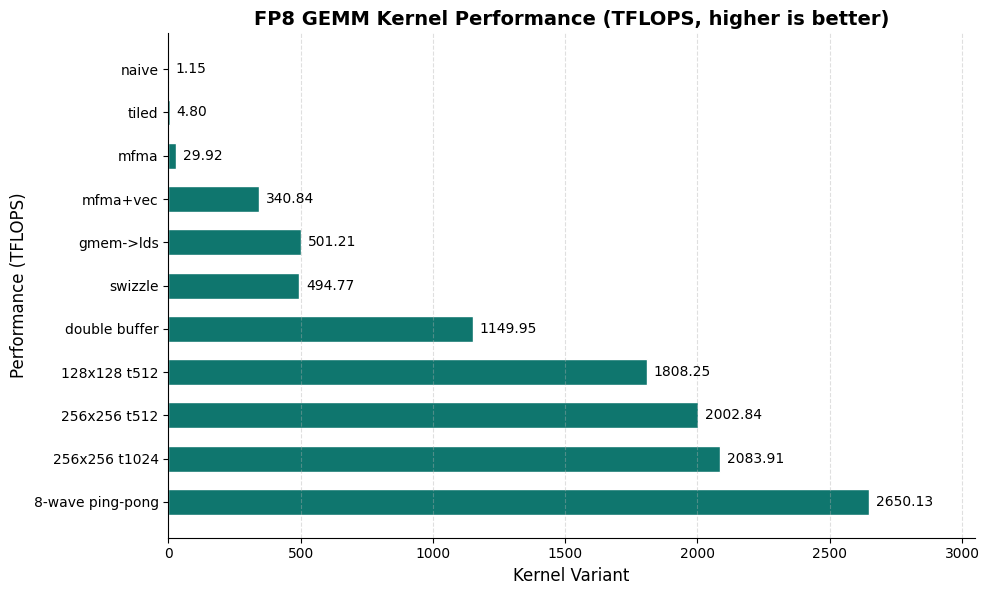

In [34]:
display_performance_chart(
    combined_results,
    value_col="avg_tflops",
    title="FP8 GEMM Kernel Performance (TFLOPS, higher is better)",
    ylabel="Performance (TFLOPS)",
    xlabel="Kernel Variant",
)

## Reference GEMM with hipBLASLt

> **Container required:** This reference section uses the `hipblaslt-bench` CLI which ships with the ROCm Docker image (`/opt/rocm/bin/hipblaslt-bench`). It may not be available on bare-metal installs unless hipBLASLt is installed separately. 

In [ ]:
import subprocess
from pathlib import Path

bench_bin = "/therock/install/bin/hipblaslt-bench"
assert Path(bench_bin).is_file(), f"hipblaslt-bench not found at {bench_bin}"
print(f"Using bench binary: {bench_bin}")


def run_hipblaslt_fp8_gemm(M, N, K, iters=50, cold_iters=5):
    """Run hipblaslt-bench with FP8 (E4M3 / f8_r) inputs and bf16 output.

    Note: We use --a_type/b_type f8_r (the OCP E4M3 variant) rather than
    f8_fnuz_r. As of ROCm 7.1, hipBLASLt's init kernel for the fnuz variant
    has a missing-symbol bug. The compute path itself is fine; only the
    bench's input-fill kernel is affected. f8_r works on CDNA4 hardware.
    """
    cmd = [
        bench_bin,
        "-m", str(M), "-n", str(N), "-k", str(K),
        "--a_type", "f8_r", "--b_type", "f8_r",
        "--c_type", "bf16_r", "--d_type", "bf16_r",
        "--compute_type", "f32_r",
        "--transA", "N", "--transB", "T",
        "--iters", str(iters), "--cold_iters", str(cold_iters),
        "--use_gpu_timer",
    ]
    out = subprocess.run(cmd, capture_output=True, text=True, check=True)
    # Last CSV line of stdout has the timing fields.
    # Filter out hipBLASLt's banner / device-info / header lines.
    data_lines = [
        l for l in out.stdout.strip().splitlines()
        if l and not l.startswith(("hip", "Q", "D", "m", "I", "[", ":", "transA", "Is "))
    ]
    last_line = data_lines[-1]
    fields = last_line.split(",")
    gflops = float(fields[-3])
    gbps   = float(fields[-2])
    us     = float(fields[-1])
    return {
        "M": M, "N": N, "K": K,
        "tflops": gflops / 1e3,
        "gbps":   gbps,
        "us":     us,
    }


# --- Benchmark the same shapes used by the hand-tuned kernels ---
for M, N, K in [(4096, 4096, 4096), (8192, 8192, 8192)]:
    result = run_hipblaslt_fp8_gemm(M=M, N=N, K=K)
    print(f"\nhipBLASLt FP8 GEMM ({M}x{N}x{K}, E4M3, bf16 out):")
    print(f"  Time:   {result['us']:.2f} us")
    print(f"  Perf:   {result['tflops']:.2f} TFLOPS")
    print(f"  BW:     {result['gbps']:.2f} GB/s")